In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
!pip install kagglehub
import kagglehub
behrad3d_nasa_cmaps_path = kagglehub.dataset_download('behrad3d/nasa-cmaps')

print('Data source import complete.')


存取被拒。


Data source import complete.


### Introduction

During their lifetime, aircraft components
are susceptible to degradation, which affects
directly their reliability and performance.
This machine learning project will be directed to provide a framework for predict-
ing the aircraft’s remaining useful life (RUL)
based on the entire life cycle data in order
to provide the necessary maintenance behavior. Diverse regression, classification
models (KNN, Naïve Bayes, Random Forest,
SVM, etc..) are deployed and tested on the
NASA’s C-MAPSS data-set to assess the
engine’s lifetime. Please check the report for more theoretical details

<div align='center' > <img src='https://i.postimg.cc/gcvWCNHf/Turbofan-operation-lbp.png'>
 </div>

<div align='center' > Illustration of a turbofan engine </div>

Our focus will be the prediction of the
RUL of the turbofan engine considering
HPC failure and more precisely capturing
low RUL values to avoid putting the engine
on risk.

This notebook will go through : Data inspection, Data visualization, Feature engineering, Regression, Classification and finishing with LSTM.

#### Importing initially important libraries


In [3]:
##匯入函式庫
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#視覺化套件 常用來觀察感測器數據趨勢、RUL 分佈、特徵關聯性

##機器學習
from sklearn.ensemble import RandomForestRegressor
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #特徵標準化（feature scaling）

#輔助工具
import os #用於檔案路徑處理、列出檔案
import random #Python 內建隨機數模組
import warnings #控制警告訊息顯示，例如隱藏版本警告或無關緊要的提醒

np.random.seed(34)#設定 隨機種子（random seed），確保每次執行結果一致
warnings.filterwarnings('ignore') #忽略所有警告訊息，讓輸出更乾淨

Note : make sure to adapt the way data is collected to your environment (If you're working on kaggle you can easily click on add data then choose nasa-cmaps data).

#### Defining features names

In [4]:
##幫資料集建立欄位名稱
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names

#### Importing train and validation data

FD001 subset corresponds to HPC failure of the engine.

Note: train data will be splitted to train/test sets in the modeling part.

In [5]:
##讀取資料
dftrain = pd.read_csv(r'C:\Users\User\Desktop\kaggle 專案\nasa專案\train_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
dftest = pd.read_csv(r'C:\Users\User\Desktop\kaggle 專案\nasa專案\test_FD001.txt',sep='\s+',header=None,index_col=False,names=col_names)
y_test = pd.read_csv(r'C:\Users\User\Desktop\kaggle 專案\nasa專案\RUL_FD001.txt',sep='\s+',header=None,index_col=False,names=['RUL'])
dftest.shape #查看資料表的「形狀（維度）」
#sep='\s+'表示以「一個或多個空白」作為欄位分隔符
#header=None 檔案第一行不是欄位名稱，只是數據，所以要關閉預設的 header 功能
#index_col=False 不把任何一欄當成索引（index）

(13096, 26)

In [6]:
##建立副本 避免連動
train = dftrain.copy()
test_ = dftest.copy()

### Data inspection

In [7]:
train

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


The dataset FD001 contains time series of 21 sensors and 3 settings of 100 units(turbofan engine).Each engine works normally at the beginning of each time series and fails at the end of the time series. Each row is a snapshot of the data taken during a single operation cycle.

In [8]:
##檢查資料規模（shape)與 驗證資料集比例
#確保「訓練與測試資料都正確讀取、格式一致、比例合理」，
#正式進入模型訓練前的最後一個 sanity check
print('Shape of the train dataset : ',train.shape)
print('Shape of the validation dataset : ',test_.shape)
print('Percentage of the validation dataset : ',len(test_)/(len(test_)+len(train)))

Shape of the train dataset :  (20631, 26)
Shape of the validation dataset :  (13096, 26)
Percentage of the validation dataset :  0.3882942449669404


In [9]:
#Cheking the presence of Nan values
#檢查訓練資料集中是否有缺失值（NaN）
print('Total None values in the train dataset : ',train.isna().sum())

Total None values in the train dataset :  unit_number    0
time_cycles    0
setting_1      0
setting_2      0
setting_3      0
s_1            0
s_2            0
s_3            0
s_4            0
s_5            0
s_6            0
s_7            0
s_8            0
s_9            0
s_10           0
s_11           0
s_12           0
s_13           0
s_14           0
s_15           0
s_16           0
s_17           0
s_18           0
s_19           0
s_20           0
s_21           0
dtype: int64


No missing value is detected

In [10]:
#敘述性分析
#查看 unit_number 與 time_cycles 的基本統計特徵，了解資料的規模與時間分佈狀況
train.loc[:,['unit_number','time_cycles']].describe()

,unit_number,time_cycles
count,20631.000000,20631.000000
mean,51.506568,108.807862
std,29.227633,68.880990
min,1.000000,1.000000
25%,26.000000,52.000000
50%,52.000000,104.000000
75%,77.000000,156.000000
max,100.000000,362.000000


When we inspect the descriptive statistics of unit_nr we can see the dataset has a total of 20631 rows, unit numbers start at 1 and end at 100 as expected. What’s interesting, is that the mean and quantiles don’t align neatly with the descriptive statistics of a vector from 1–100, this can be explained due to each unit having different max time_cycles and thus a different number of rows. When inspecting the max time_cycles you can see the engine which failed the earliest did so after 128 cycles, whereas the engine which operated the longest broke down after 362 cycles. The average engine breaks between 199 and 206 cycles, however the standard deviation of 46 cycles is rather big. We’ll visualize this further down below to get an even better understanding.

In [11]:
#針對所有感測器（s_1～s_21）做統計摘要
#用 .transpose() 轉成橫向排列，方便比較各感測器的分佈
#幫助我們了解哪些感測器變化明顯(可能故障)、哪些感測器幾乎不變(功能穩定)
train.loc[:,'s_1':].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
s_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
s_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
s_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
s_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000


### Data visualization & Feature engineering

### Max time cycle found for each Unit

Let us see the maximum time cycle of each unit

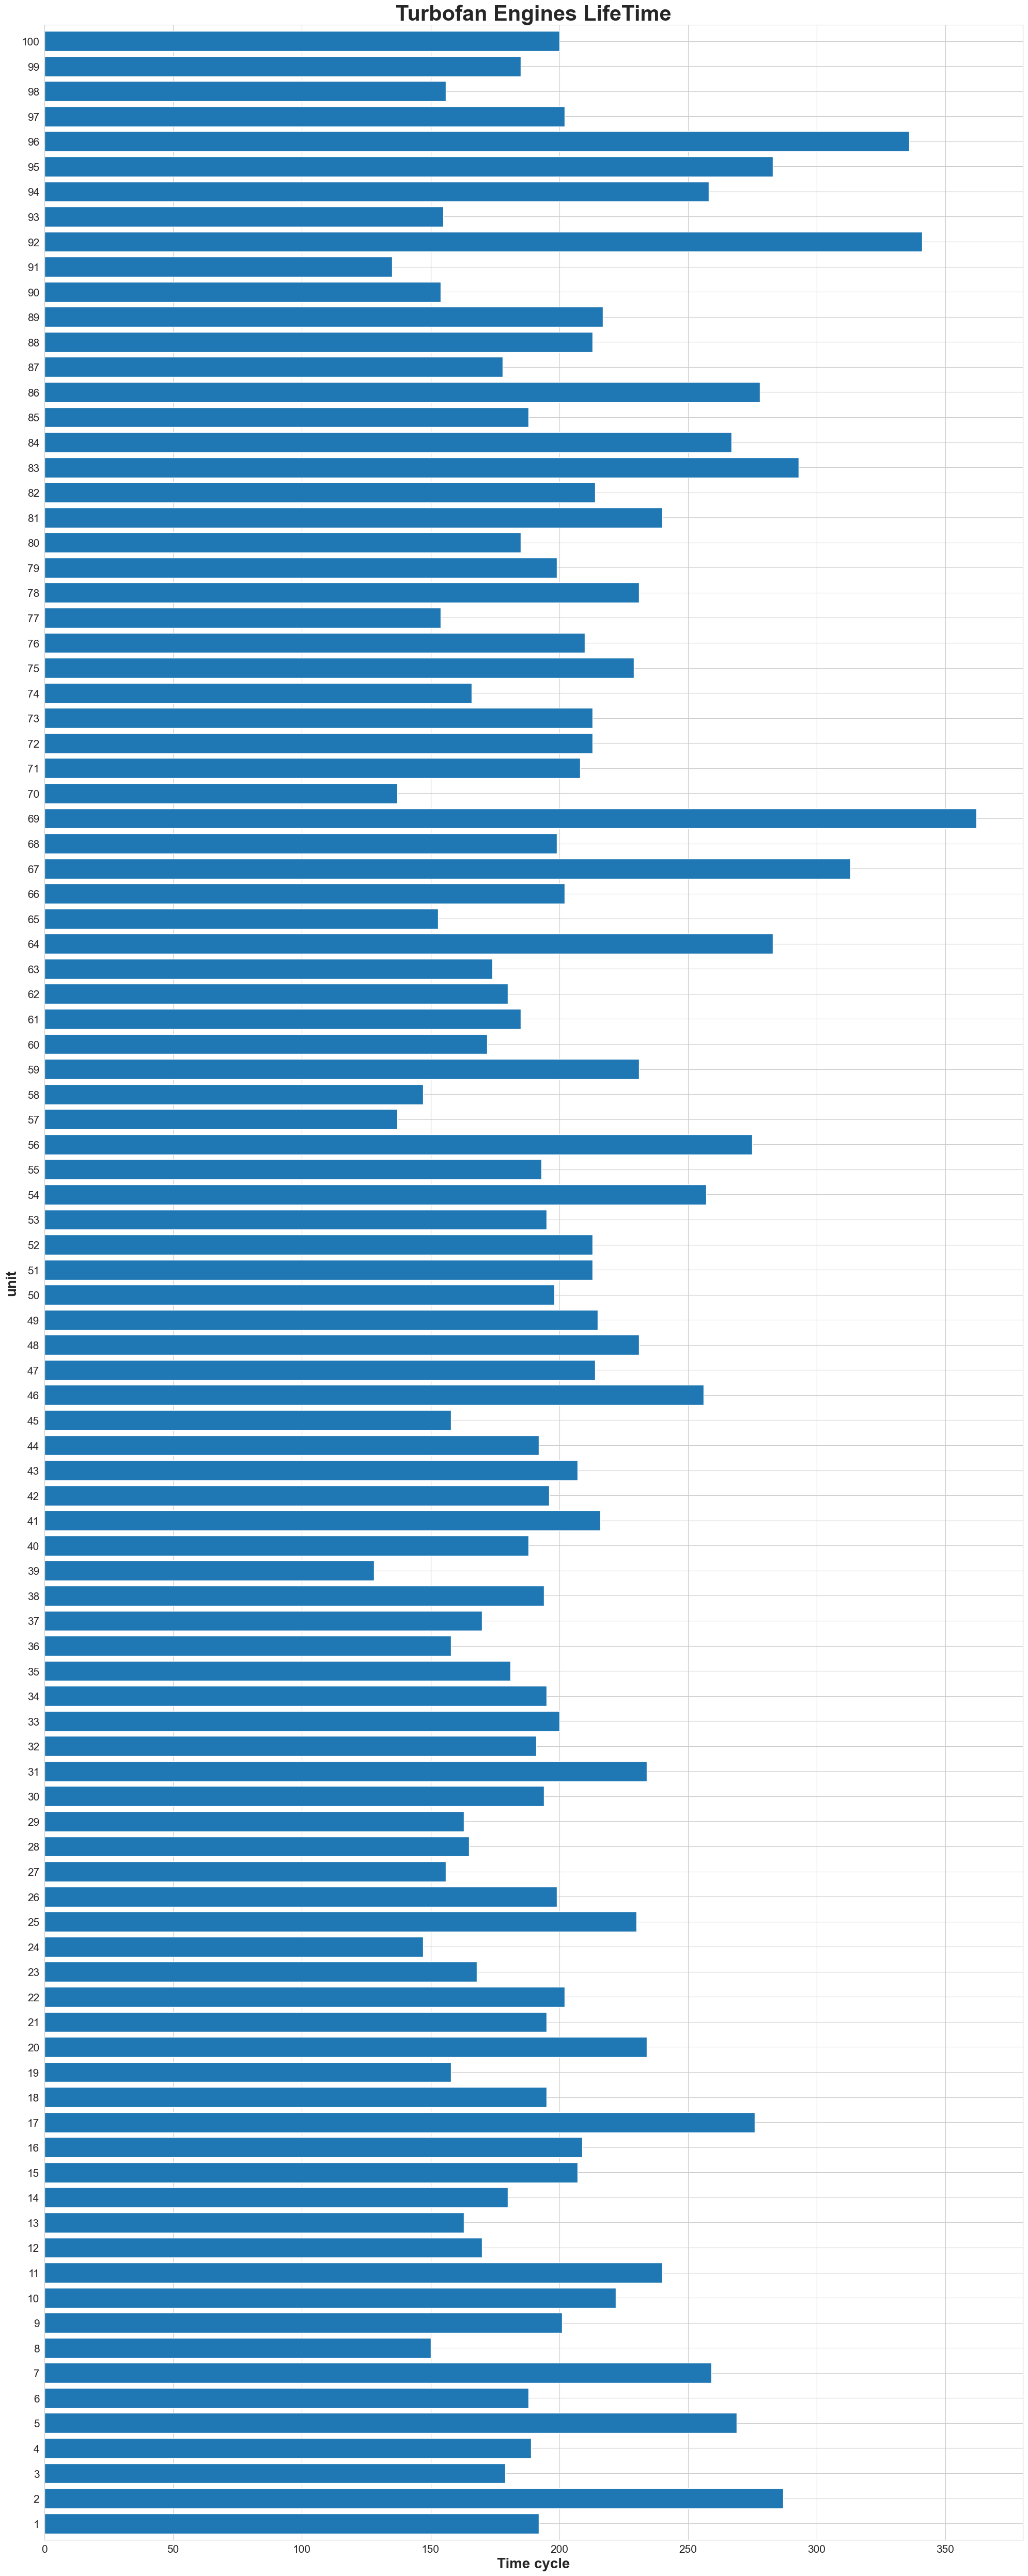

In [12]:
##視覺化每一台渦輪風扇引擎（Turbofan Engine）在訓練資料中運作的總生命週期長度(找出最大的cycle)
max_time_cycles=train[index_names].groupby('unit_number').max()#取出train裡面的indexname變數，並以unitnumber分組並取出最大cycletime
plt.figure(figsize=(20,50))#設定整張圖的大小（寬 20、高 50 英吋）
ax=max_time_cycles['time_cycles'].plot(kind='barh',width=0.8, stacked=True,align='center')
#ax 畫圖區域
#max_time_cycles['time_cycles']從max_time_cycles裡取出time cycle
#.plot 是 Pandas 內建的繪圖方法
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Time cycle',fontweight='bold',size=20)
plt.xticks(size=15) #調整刻度字體大小
plt.ylabel('unit',fontweight='bold',size=20)
plt.yticks(size=15)
plt.grid(True) #加入背景格線，方便對比
plt.tight_layout() #自動調整邊距，避免標籤被切掉
plt.show()

Text(0.5, 9.44444444444448, 'max time cycle')

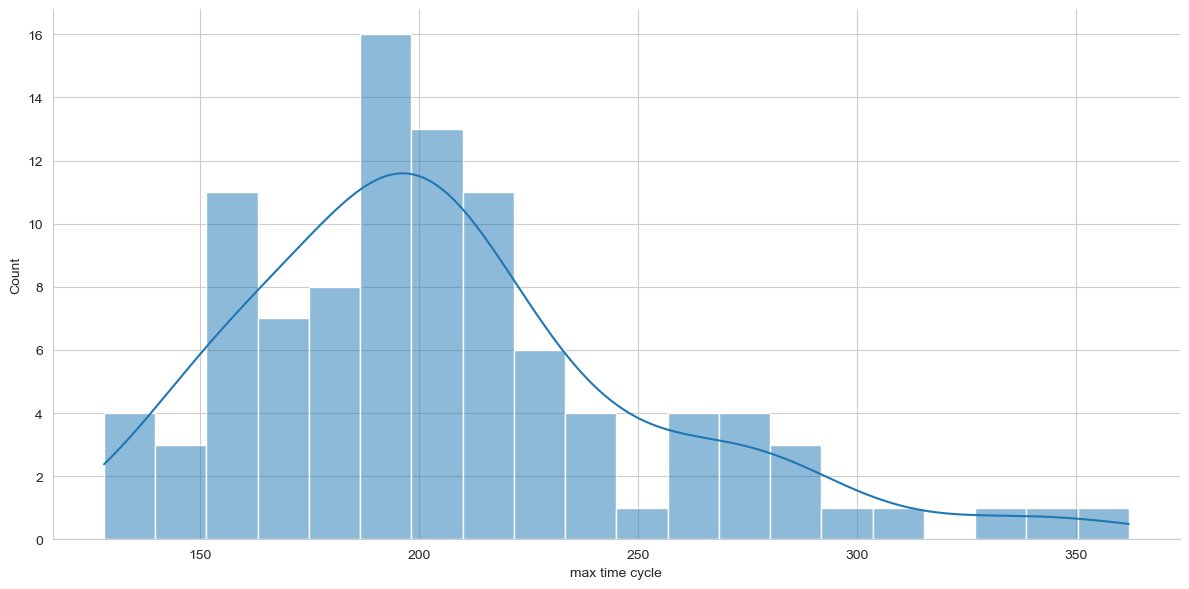

In [13]:
##了解引擎壽命的整體分佈狀況
#Distribution of maximum time cycles
sns.displot(max_time_cycles['time_cycles'],kde=True,bins=20,height=6,aspect=2)
#Seaborn 的繪圖函式，用來畫出分佈圖（distribution plot）。
plt.xlabel('max time cycle')

We notice that in most of the time, the maximum time cycles that an engine can achieve is between 190 and 210 before HPC failure.

### Add RUL column to the data

###### RUL  corresponds to the remaining time cycles for each unit before it fails.

In [14]:
##在訓練資料中新增RUL欄位(LABELING)
#自己計算出 RUL 並加入訓練資料
def add_RUL_column(df): #df單純為函數裡的變數
    train_grouped_by_unit = df.groupby(by='unit_number')
    max_time_cycles = train_grouped_by_unit['time_cycles'].max()
    ##在外面寫過在裡面還要再寫一次嗎??
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    #合併df 和max_time_cycles
    #[] 新增/取出
    merged["RUL"]= merged["max_time_cycle"] - merged['time_cycles']
    #計算每個時間點(time cycle)下各自的RUL
    merged = merged.drop("max_time_cycle", axis=1)
    return merged

In [15]:
train = add_RUL_column(train)
#將train帶入df 獲得新的train

In [16]:
train[['unit_number','RUL']]

,unit_number,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
20626,100,4
20627,100,3
20628,100,2
20629,100,1


In [17]:
#Rul analysis#最大RUL(發生在機器開始運轉時)最大TIME CYCLE 只是最大TIME CYCLE發生在瀕臨故障時
maxrul_u = train.groupby('unit_number').max().reset_index()
#groupby 之後，unit_number 會變成 index
#reset_index() 把它變回一般欄位，方便後續操作或顯示
maxrul_u.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,192,0.0047,0.0005,100.0,518.67,644.21,1605.44,1432.52,14.62,...,2388.35,8140.58,8.5227,0.03,398,2388,100.0,39.18,23.4999,191
1,2,287,0.0076,0.0006,100.0,518.67,643.94,1610.10,1431.17,14.62,...,2388.26,8175.57,8.5377,0.03,398,2388,100.0,39.24,23.6005,286
2,3,179,0.0058,0.0005,100.0,518.67,643.93,1606.50,1438.51,14.62,...,2388.20,8255.34,8.5363,0.03,399,2388,100.0,39.23,23.5181,178
3,4,189,0.0059,0.0006,100.0,518.67,644.53,1612.11,1434.12,14.62,...,2388.17,8259.42,8.5462,0.03,399,2388,100.0,39.21,23.5074,188
4,5,269,0.0055,0.0005,100.0,518.67,644.02,1609.41,1434.59,14.62,...,2388.23,8215.19,8.5410,0.03,398,2388,100.0,39.29,23.5503,268


### Discovering Correlations

<Axes: >

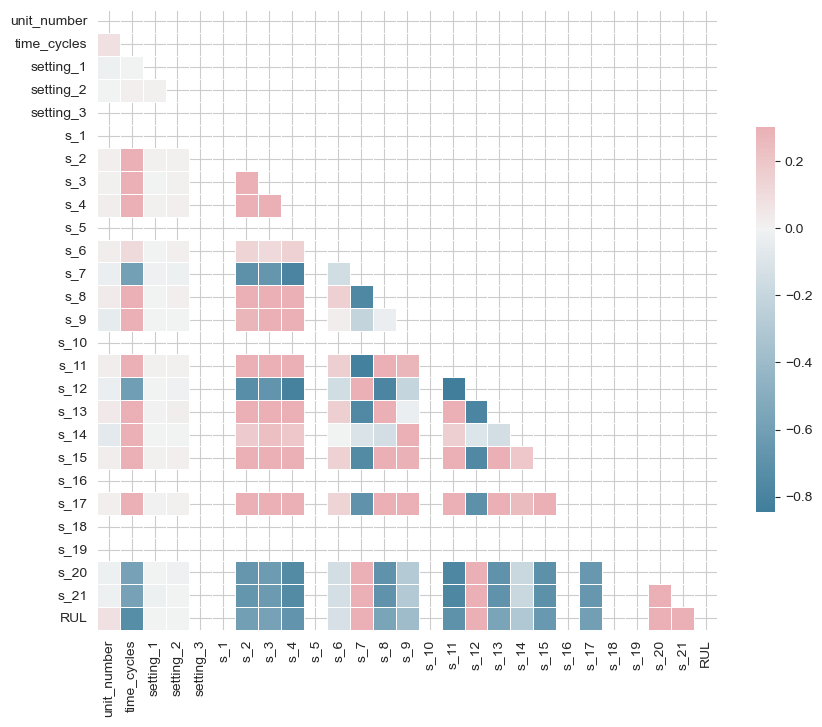

In [18]:
##相關係數矩陣（Correlation Matrix）分析，並用 熱圖（Heatmap） 可視化不同欄位之間的相關性
# Compute the correlation matrix
corr = train.corr()#計算 所有數值欄位之間的皮爾森相關係數（Pearson correlation）

#np.ones_like(corr) → 建一個跟 corr 一樣大小的矩陣，元素全是 1
#np.triu(...) → 只保留 上三角，其餘設為 False
#目的：相關矩陣是對稱的，上三角跟下三角一樣，只畫一半就足夠，看起來更整潔
mask = np.triu(np.ones_like(corr, dtype=bool))

#建立一個 10x10 吋的畫布，用來畫熱圖
#fig → 整個畫布 整個圖表都放在這個畫布上
#ax → 單個或多個座標軸 畫布上實際繪圖的區域
f, ax = plt.subplots(figsize=(10, 10))
#產生一個分歧色彩盤
#適合表示正負相關：紅色 → 負相關，藍色 → 正相關
#變成 matplotlib 可以使用的 colormap
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,square=True, linewidths=.5, cbar_kws={"shrink": .5})

We notice that some features of our data-set are highly correlated with the target value RUL, other features present a low correlation which will be dropped later.

### Questions to answer :

- Can we efficiently predict the remaining useful time for the engine (error significance) ?
- Which features are the most important for predicting the failure of the turbofan engine ?
- Does adding historical data improve our model ?
- Is the collected data sufficient enough to give an accurate prediction ?
- How can we turn our problem to a classification one ?


First, let us match each sensor with its real signification

In [19]:
Sensor_dictionary={}
#建立 sensor 說明列表
dict_list=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
#用迴圈填入字典
i=1
for x in dict_list: #[::-1]
    Sensor_dictionary['s_'+str(i)]=x
    i+=1
Sensor_dictionary

{'s_1': '(Fan inlet temperature) (◦R)',
 's_2': '(LPC outlet temperature) (◦R)',
 's_3': '(HPC outlet temperature) (◦R)',
 's_4': '(LPT outlet temperature) (◦R)',
 's_5': '(Fan inlet Pressure) (psia)',
 's_6': '(bypass-duct pressure) (psia)',
 's_7': '(HPC outlet pressure) (psia)',
 's_8': '(Physical fan speed) (rpm)',
 's_9': '(Physical core speed) (rpm)',
 's_10': '(Engine pressure ratio(P50/P2)',
 's_11': '(HPC outlet Static pressure) (psia)',
 's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 's_13': '(Corrected fan speed) (rpm)',
 's_14': '(Corrected core speed) (rpm)',
 's_15': '(Bypass Ratio) ',
 's_16': '(Burner fuel-air ratio)',
 's_17': '(Bleed Enthalpy)',
 's_18': '(Required fan speed)',
 's_19': '(Required fan conversion speed)',
 's_20': '(High-pressure turbines Cool air flow)',
 's_21': '(Low-pressure turbines Cool air flow)'}

A **low pressure compressor (LPC**) and **high pressure compressor
(HPC**) supply compressed high temperature, high pressure gases to the combustor.
**Low pressure turbine (LPT)** can decelerate and pressurize air to improve the chemical energy
conversion efficiency of aviation kerosene.
**High pressure turbines (HPT)** generate mechanical energy by using high temperature and high pressure gas strike turbine blades.
**Low-pressure rotor (N1), high-pressure rotor (N2), and nozzle** guarantee the combustion
efficiency of the engine.

#### Plotting the evolution of features (sensors) along with the evolution with RUL

In [20]:
#畫單一 sensor 隨 RUL 變化趨勢的函數
def plot_signal(df, Sensor_dic, signal_name):
    plt.figure(figsize=(13,5))
    for i in df['unit_number'].unique():
        if (i % 10 == 0):   #For a better visualisation, we plot the sensors signals of 20 units only
            plt.plot('RUL', signal_name, data=df[df['unit_number']==i].rolling(10).mean())

    plt.xlim(250, 0)  # reverse the x-axis so RUL counts down to zero
    plt.xticks(np.arange(0, 300, 25))
    plt.ylabel(Sensor_dic[signal_name])
    plt.xlabel('Remaining Useful Life')
    plt.show()


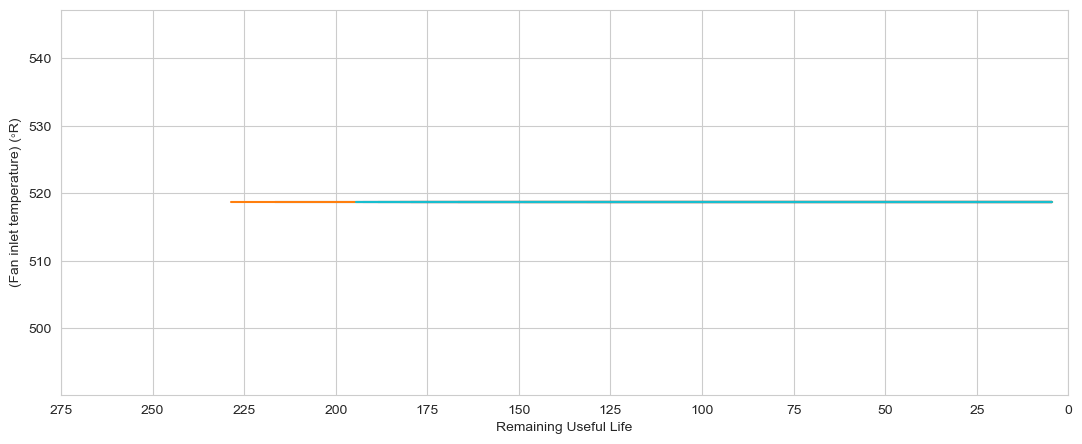

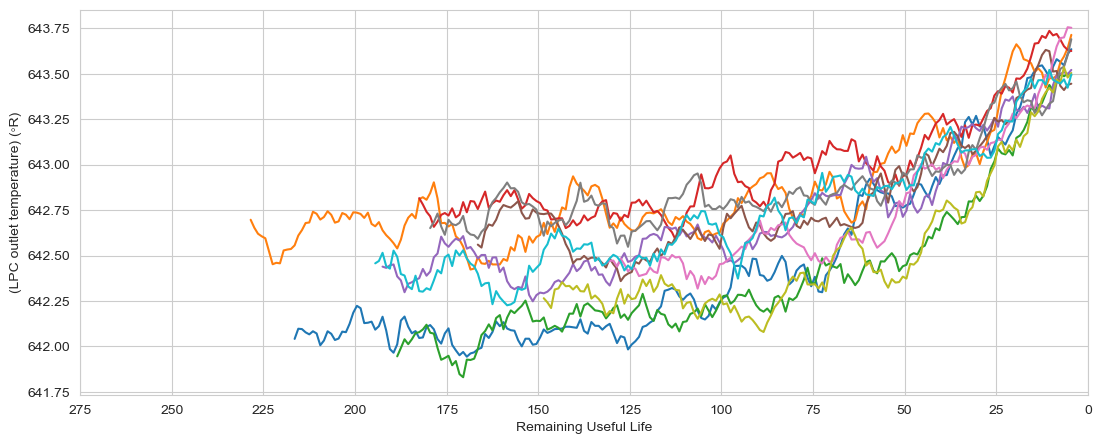

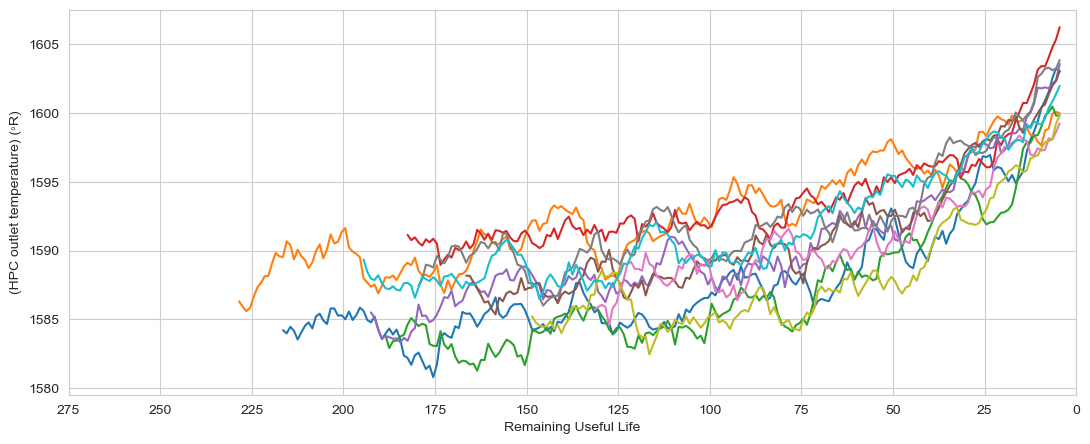

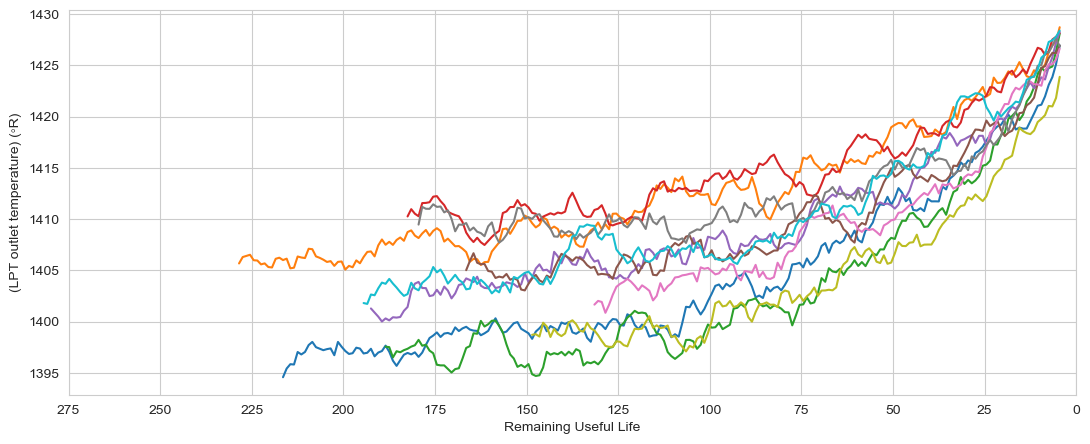

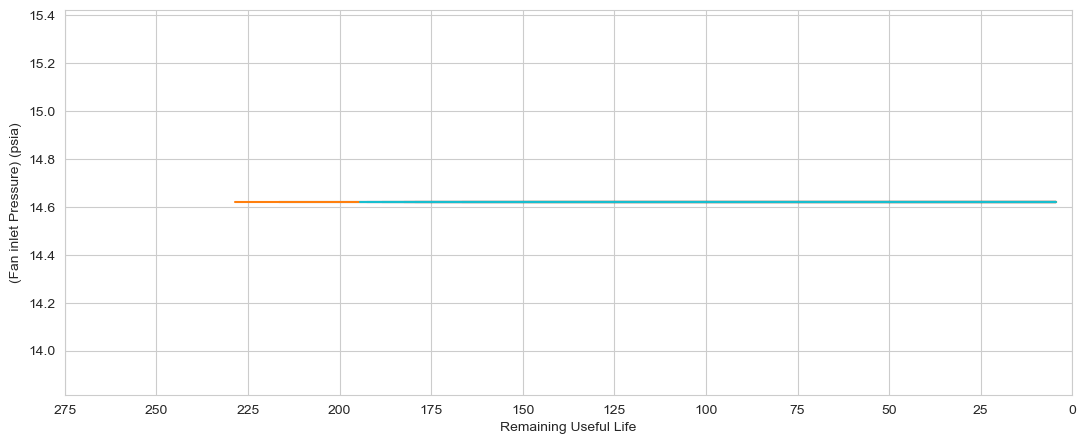

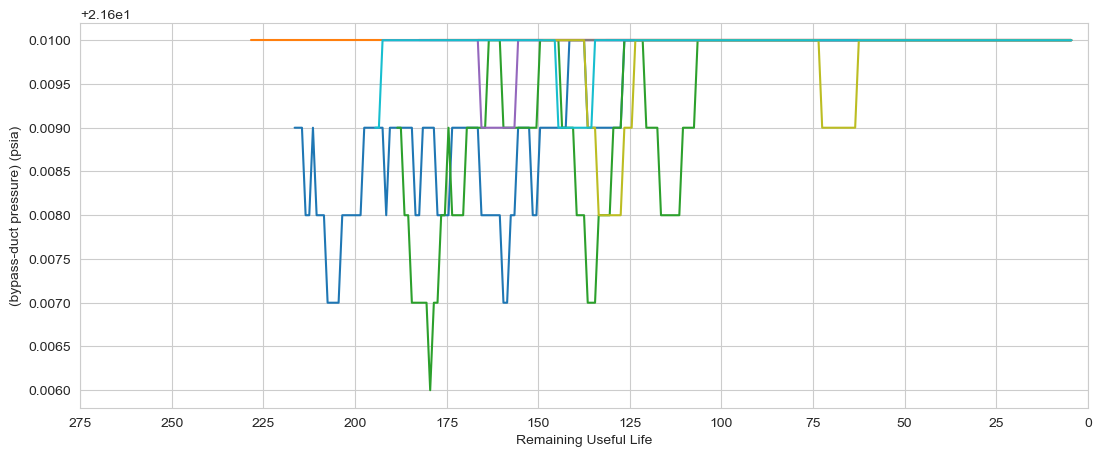

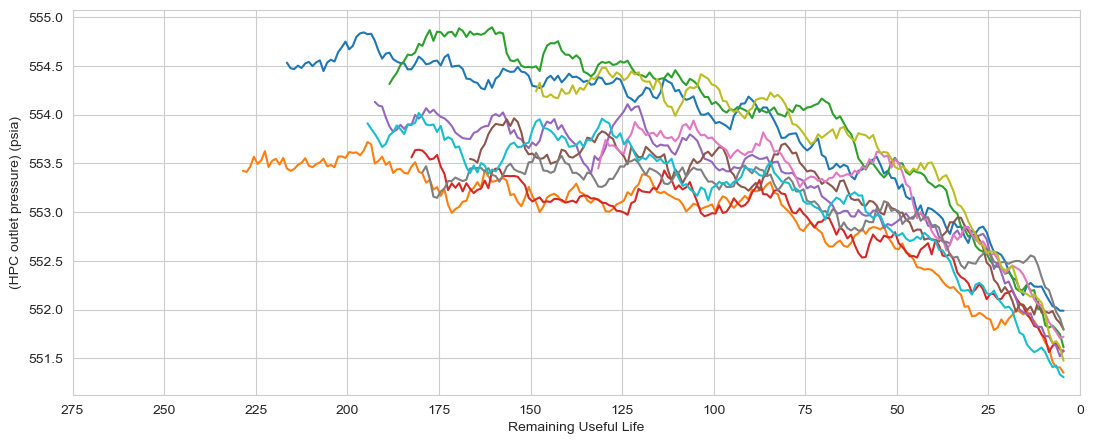

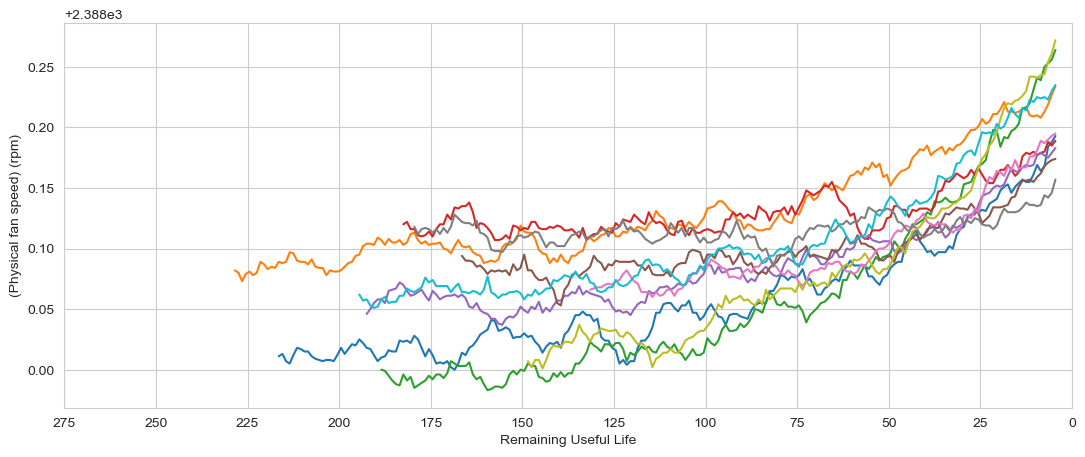

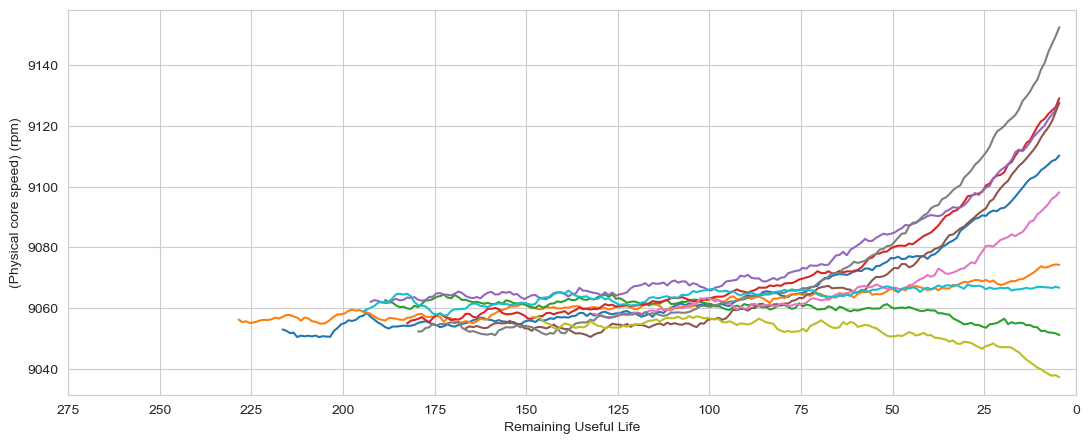

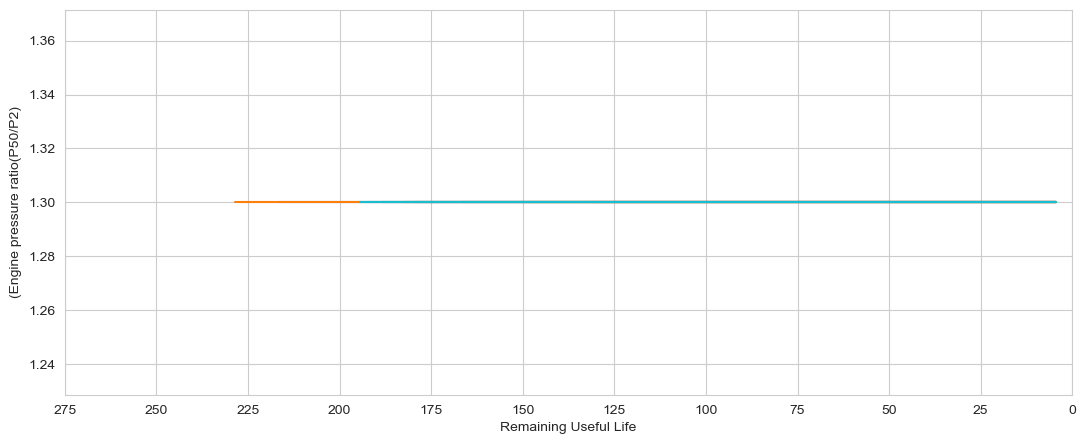

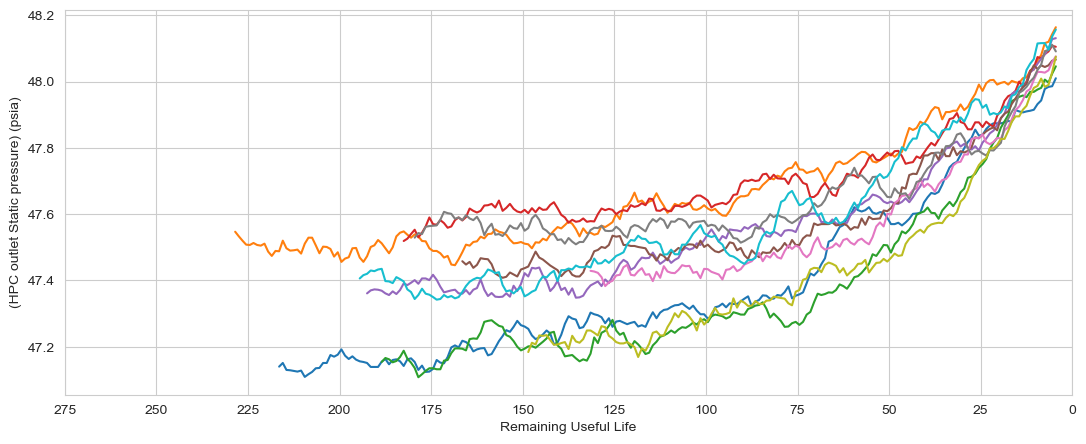

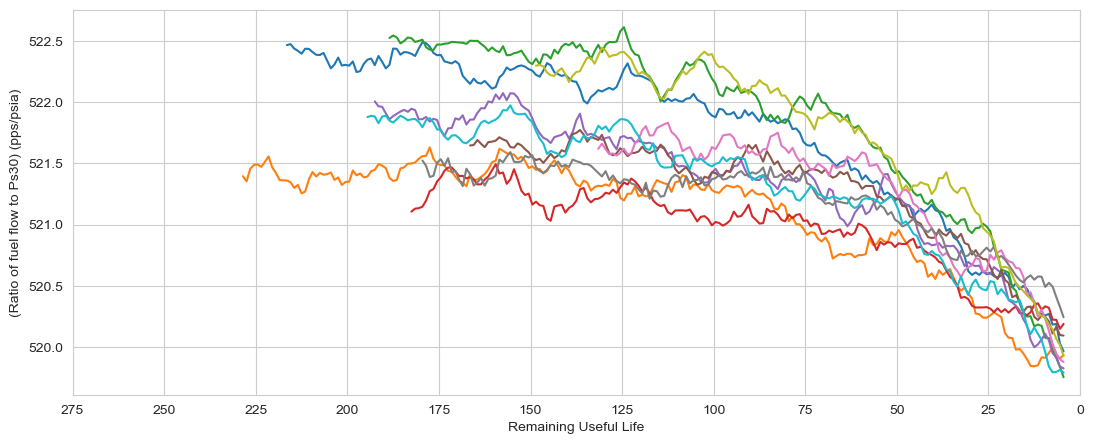

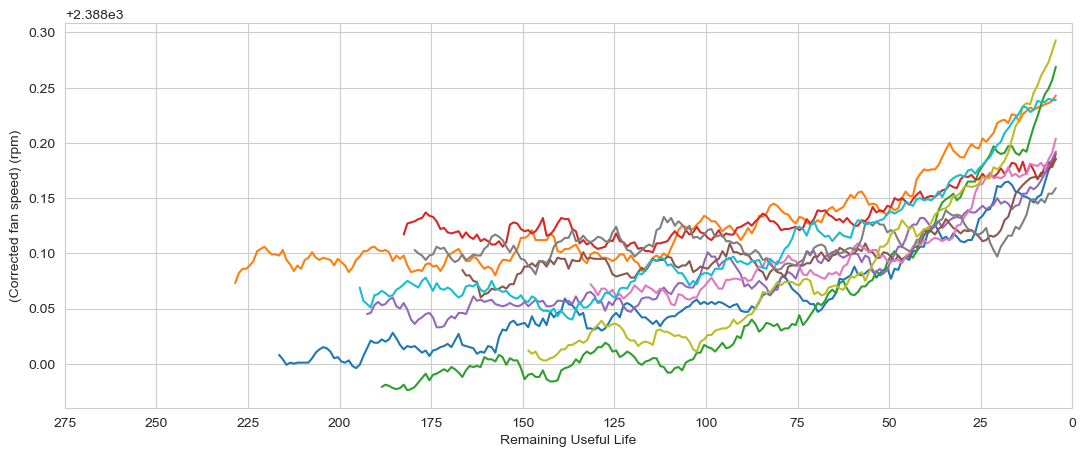

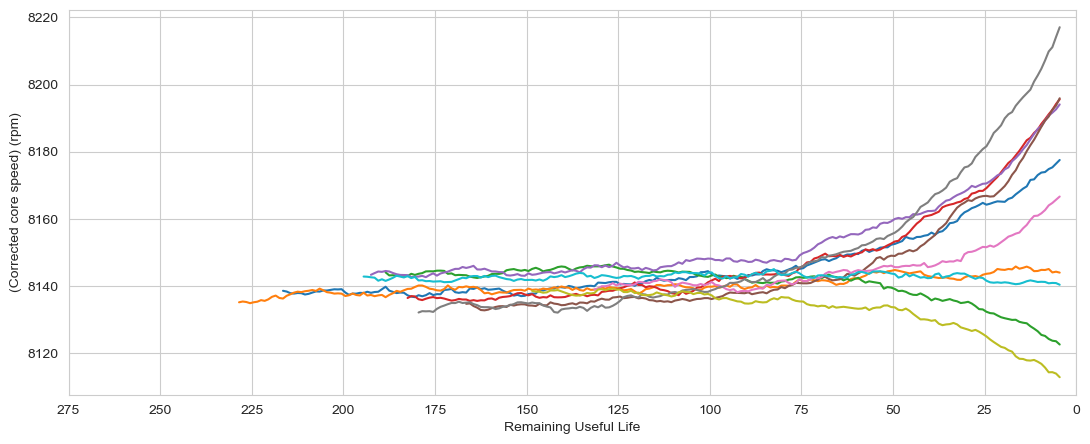

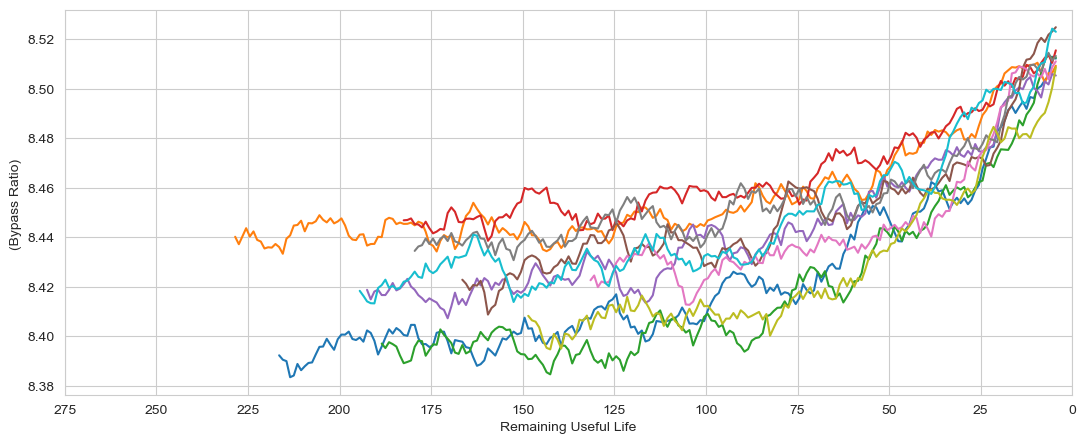

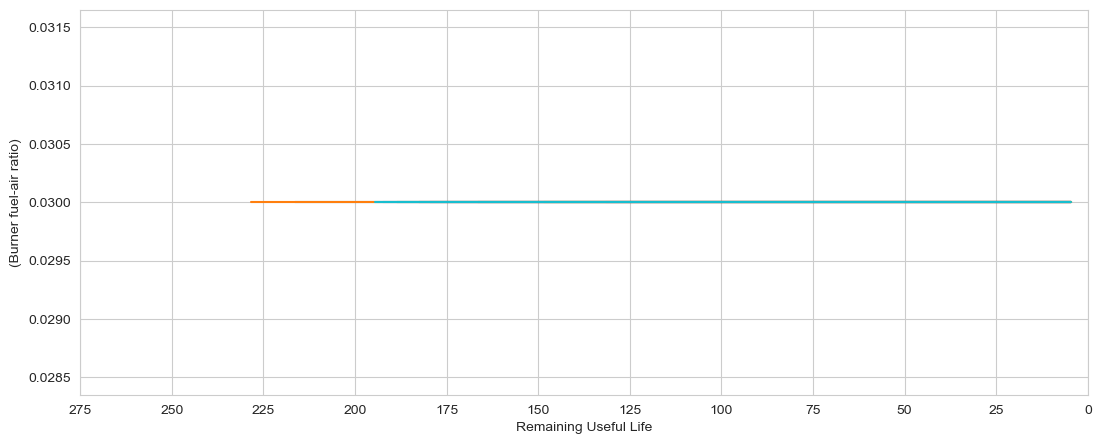

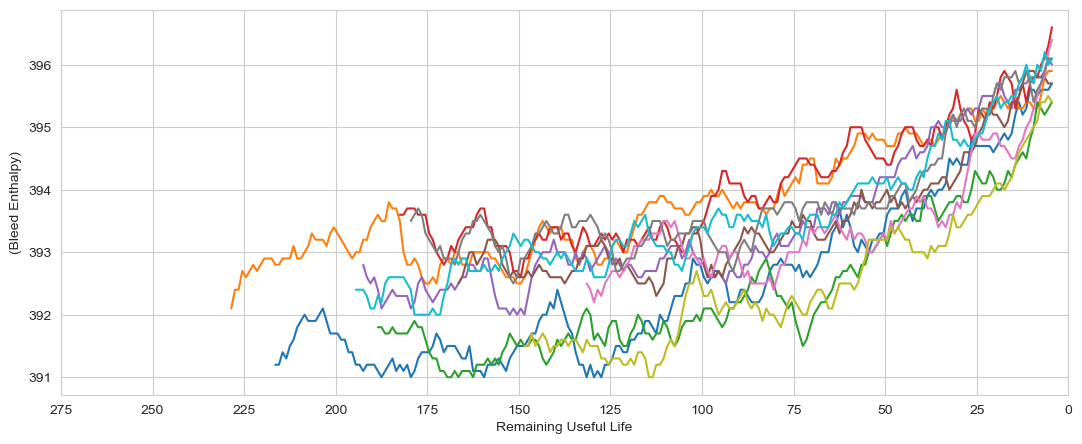

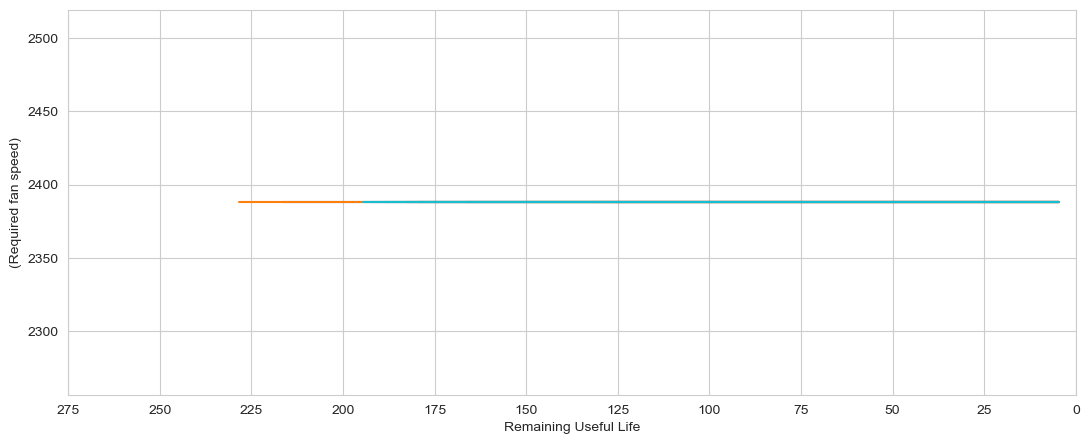

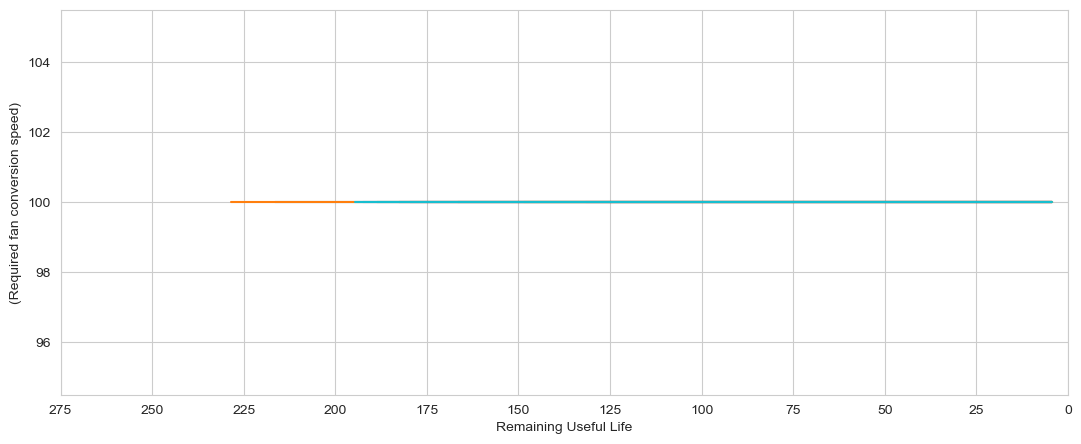

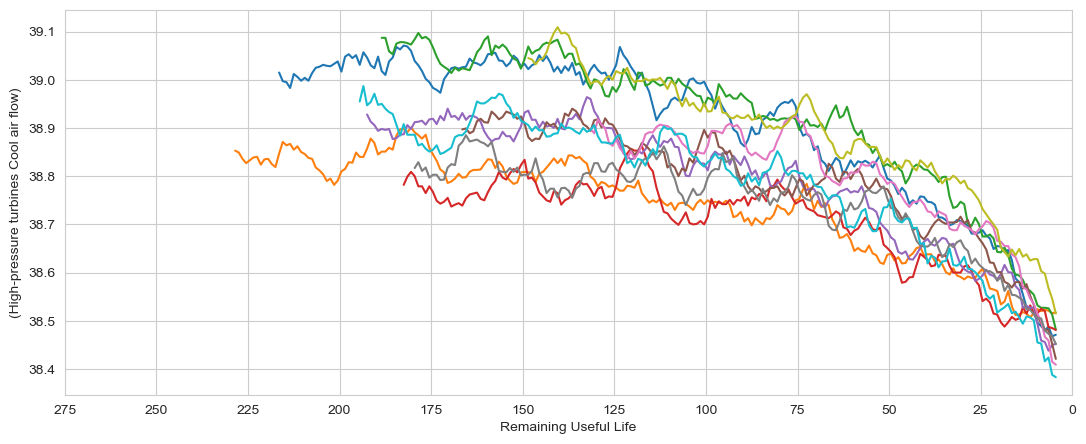

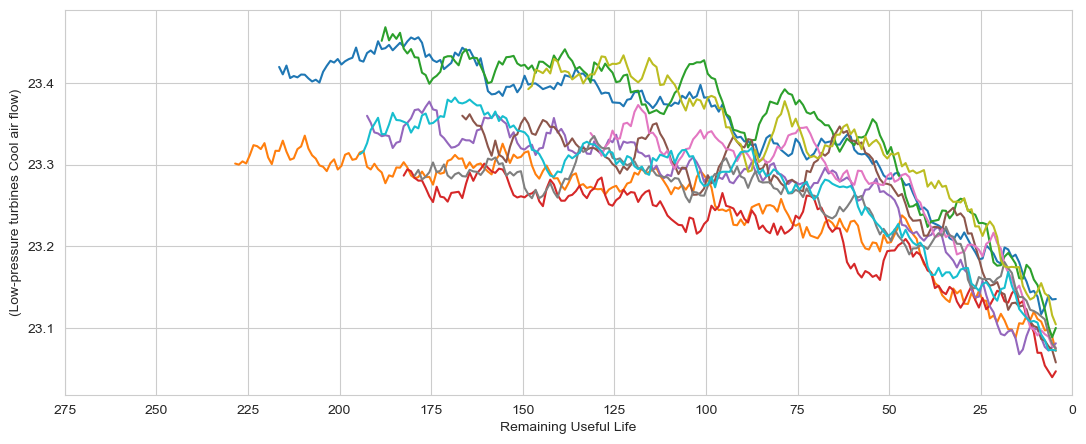

In [21]:
#批次繪製所有 21 個 sensor 的 RUL 趨勢圖
for i in range(1,22):
    try:
        plot_signal(train, Sensor_dictionary,'s_'+str(i))
    except:
        pass

These plots show that some sensors are constant. Hence they don't influence the RUL ==> we can drop those ones. (later)
有些feature對RUL無影響 因此可考慮剔除

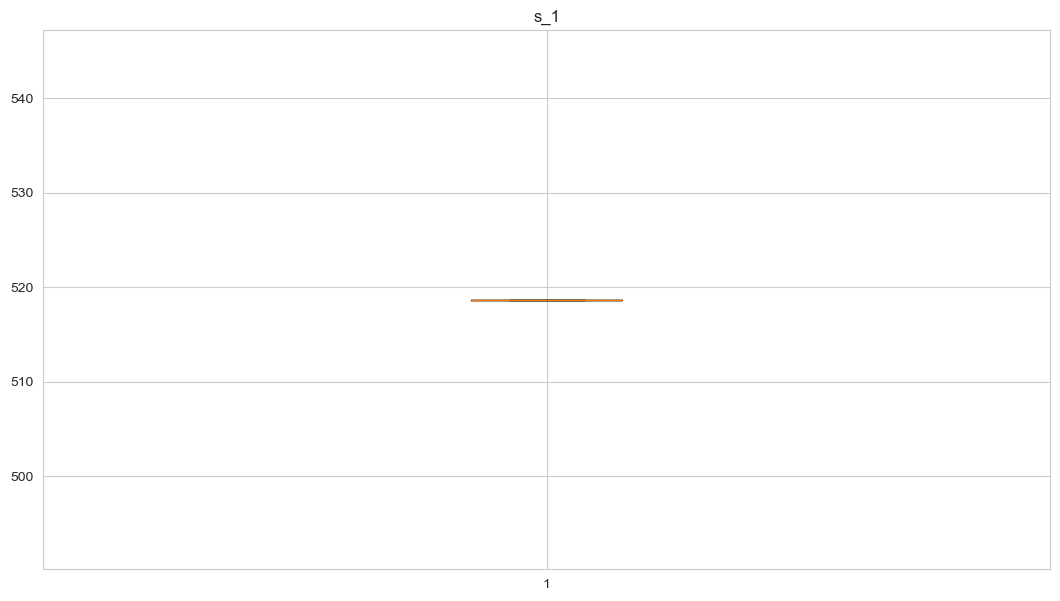

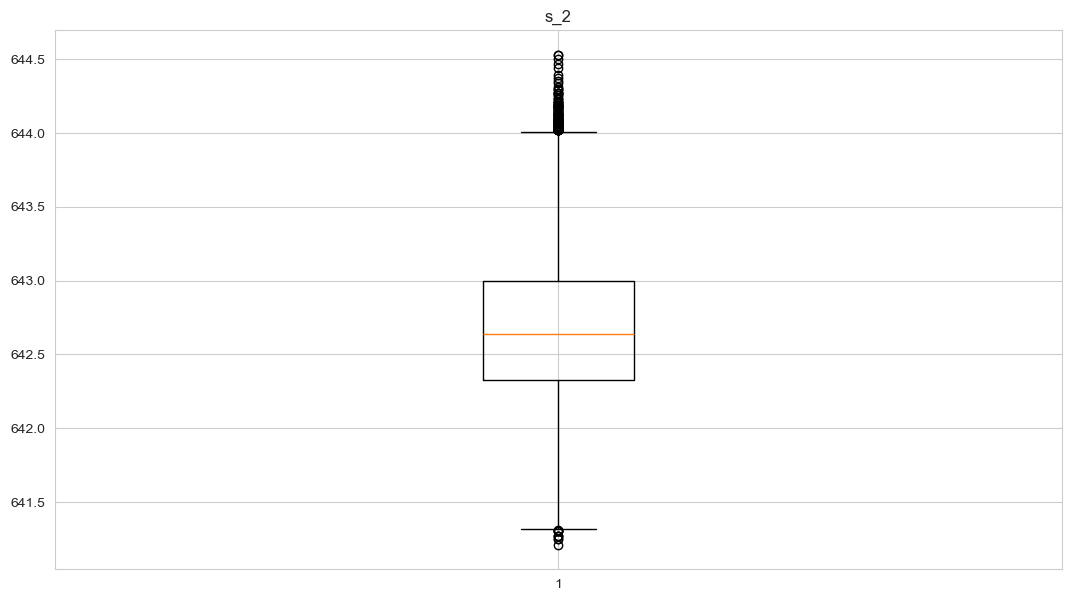

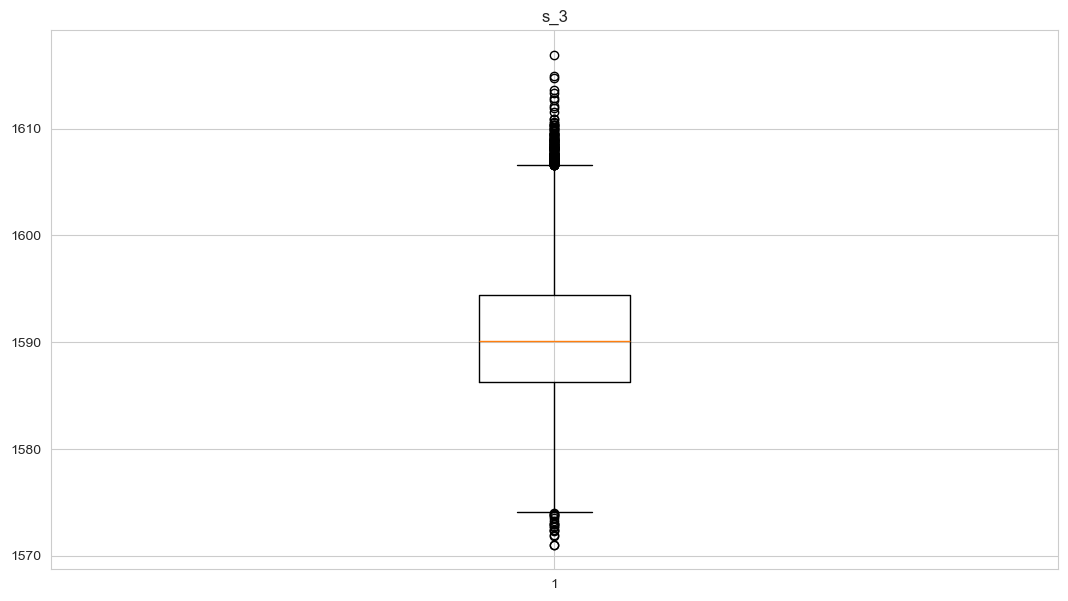

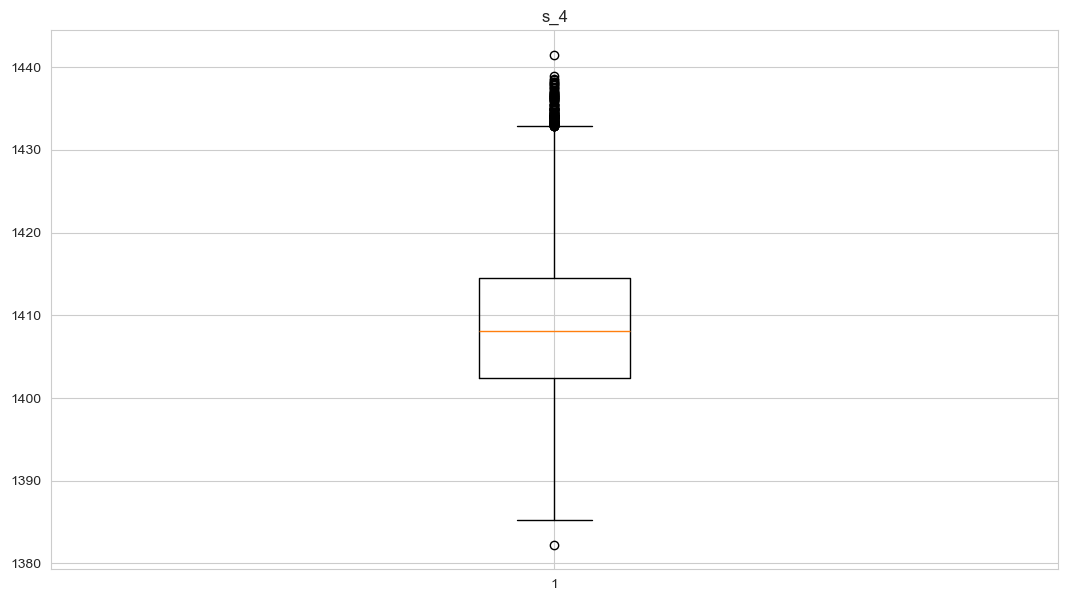

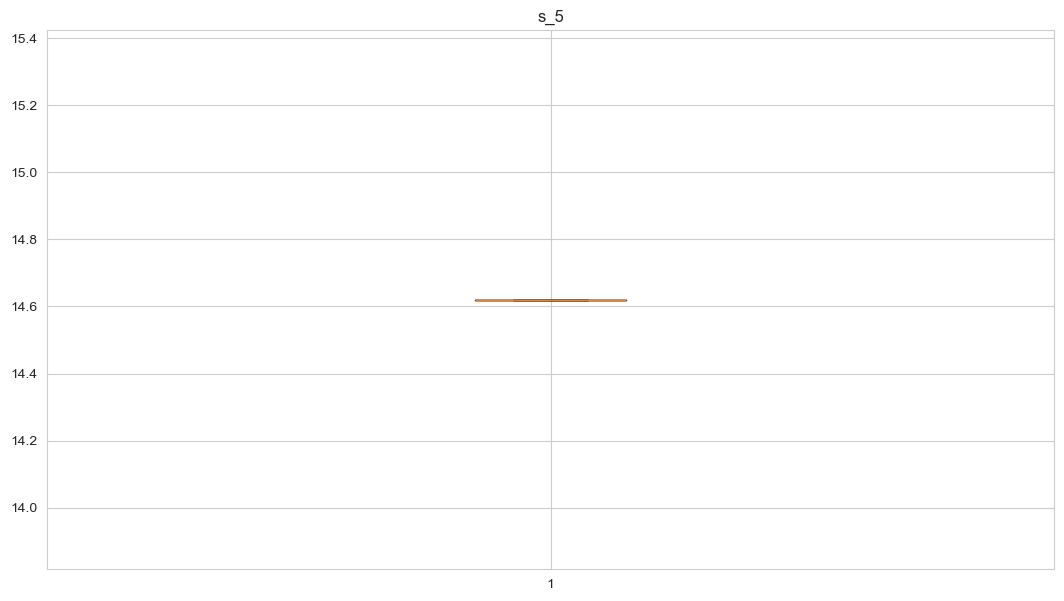

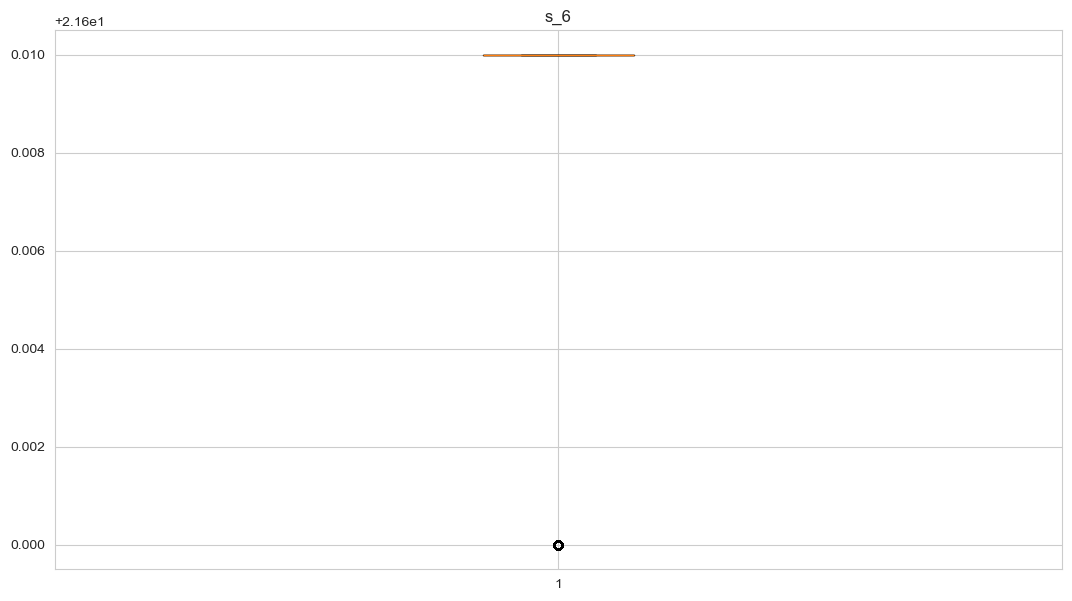

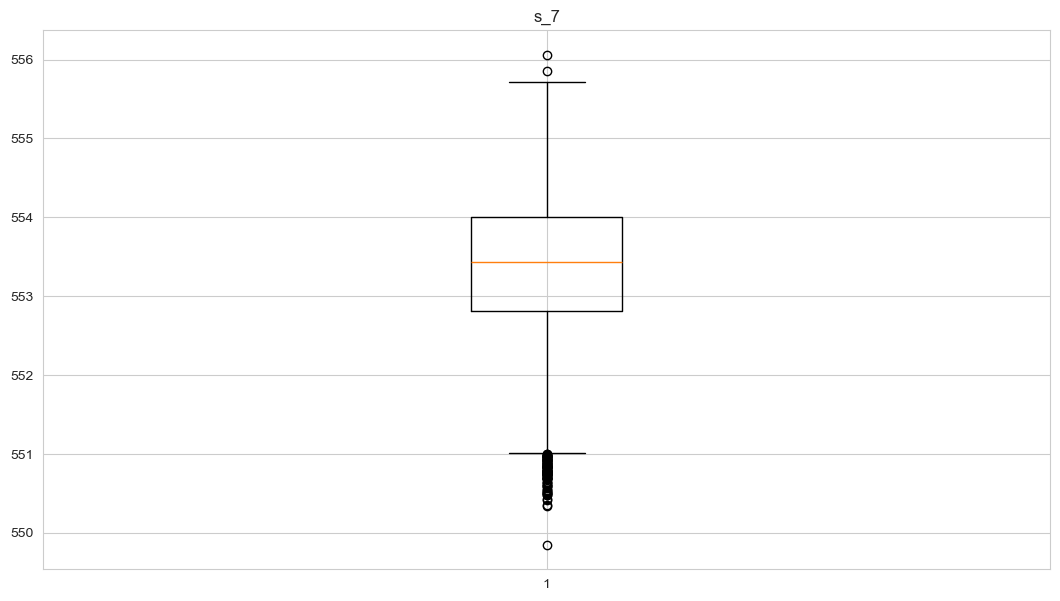

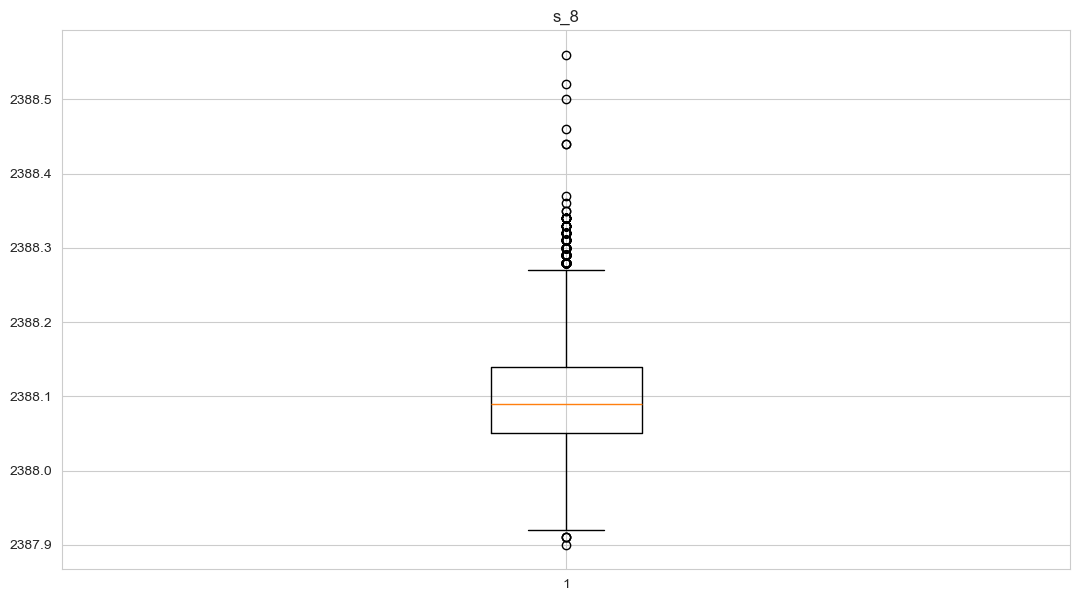

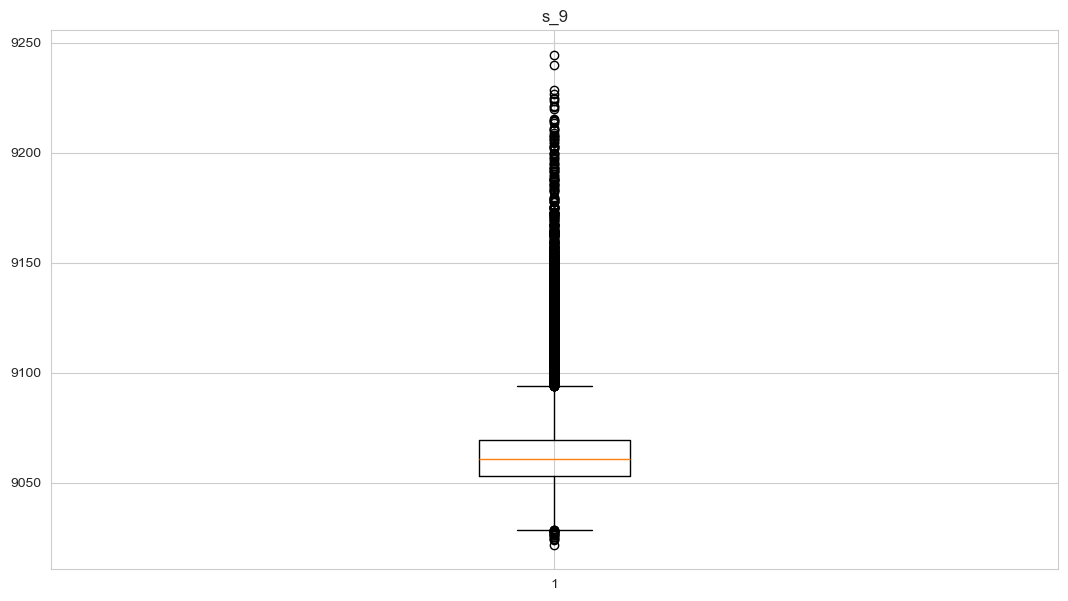

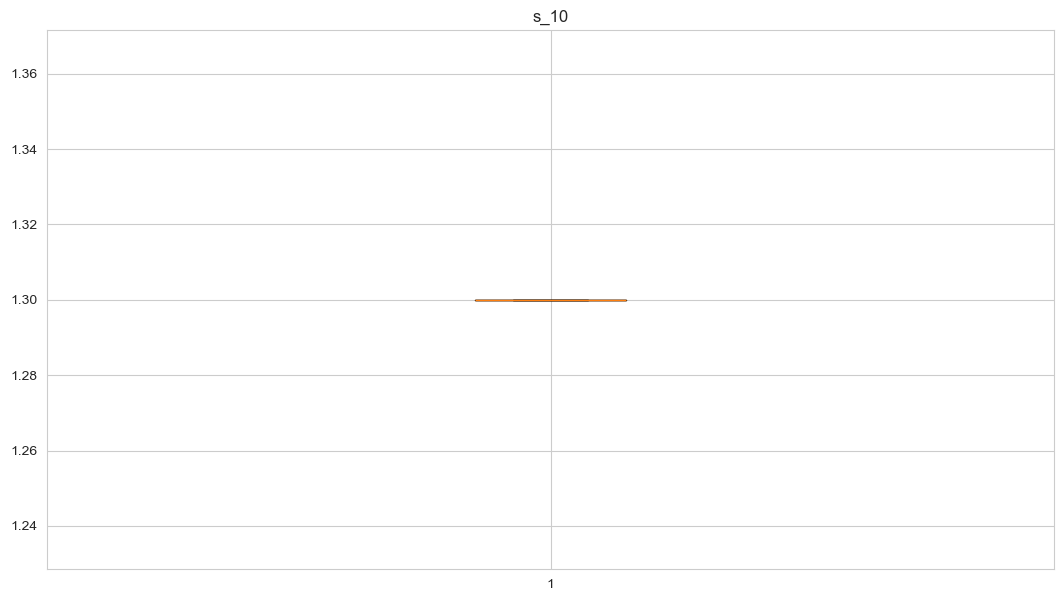

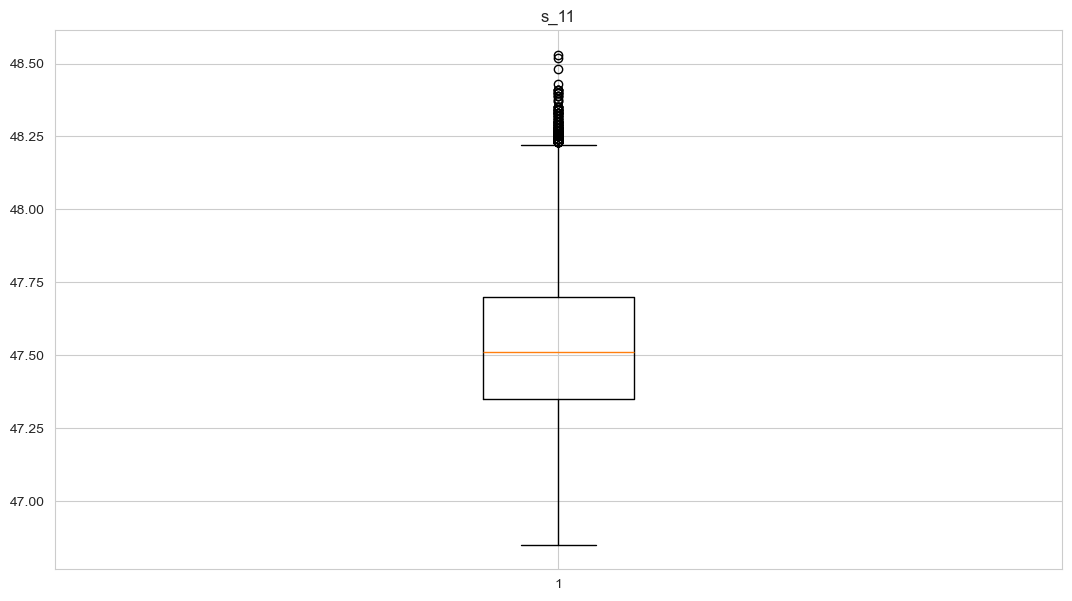

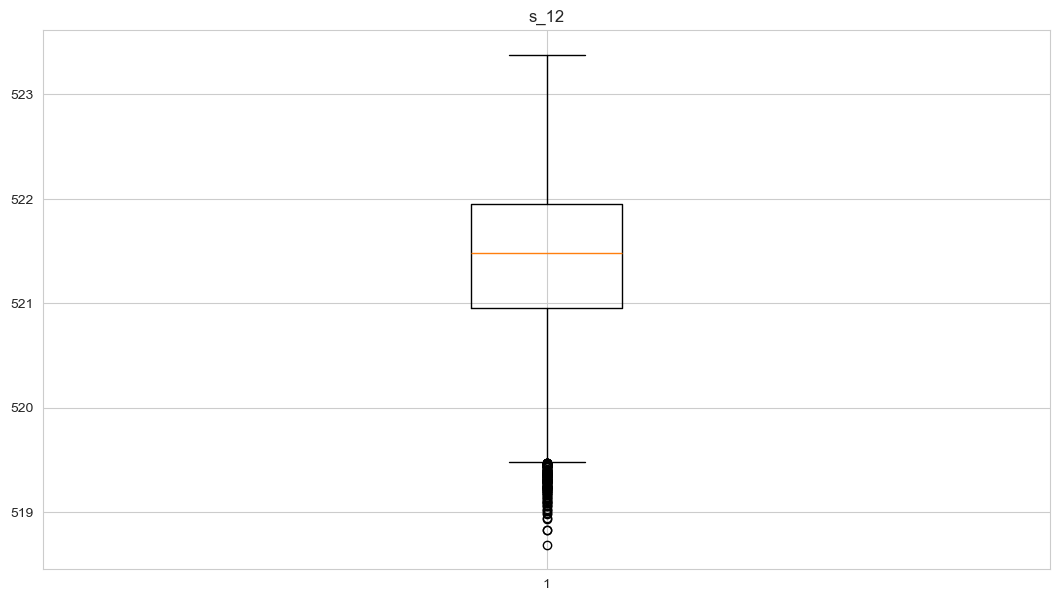

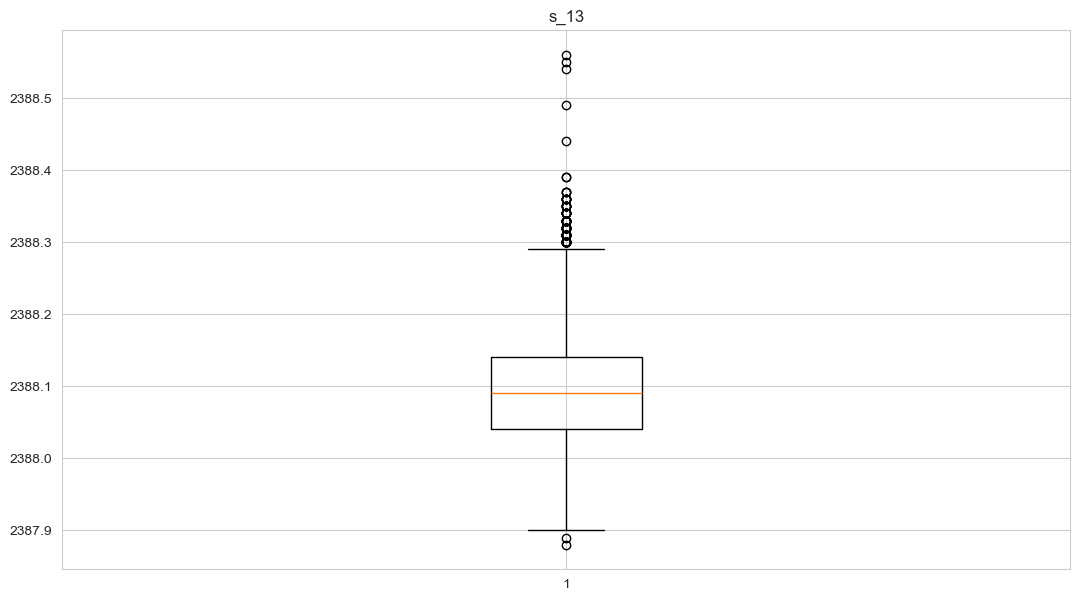

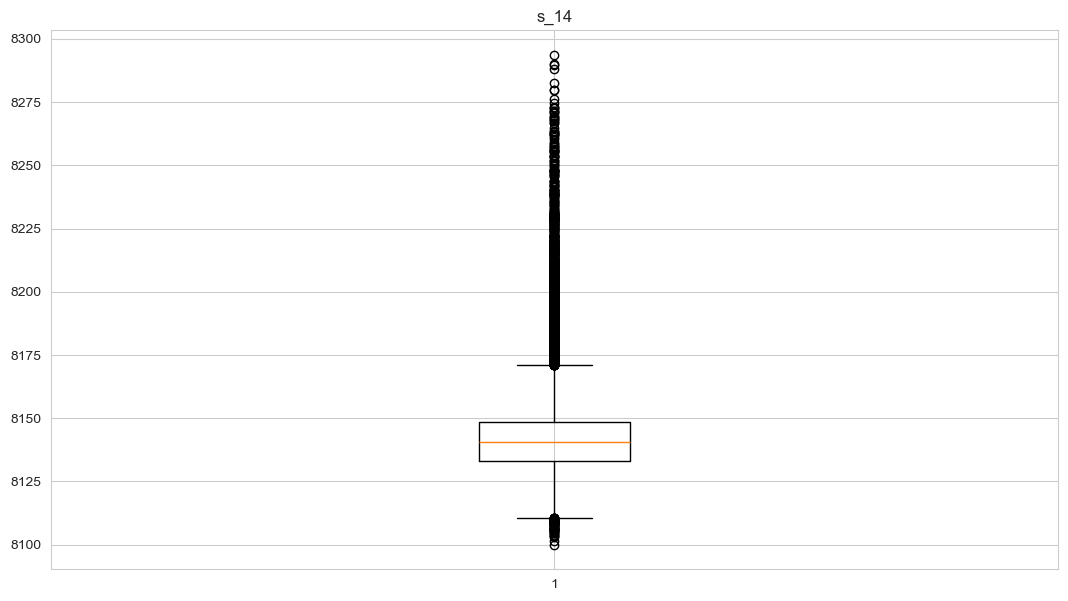

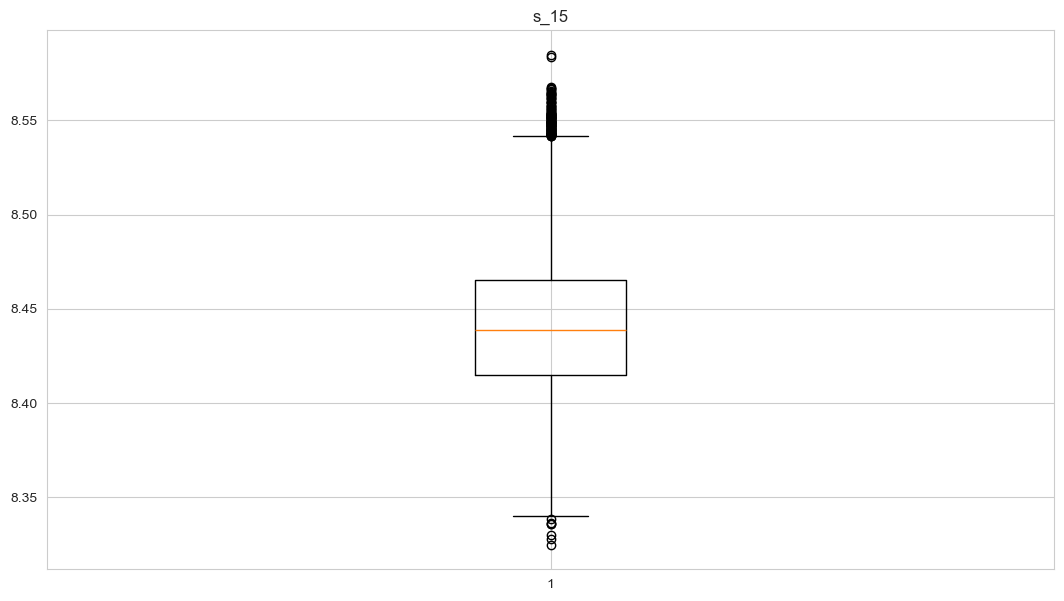

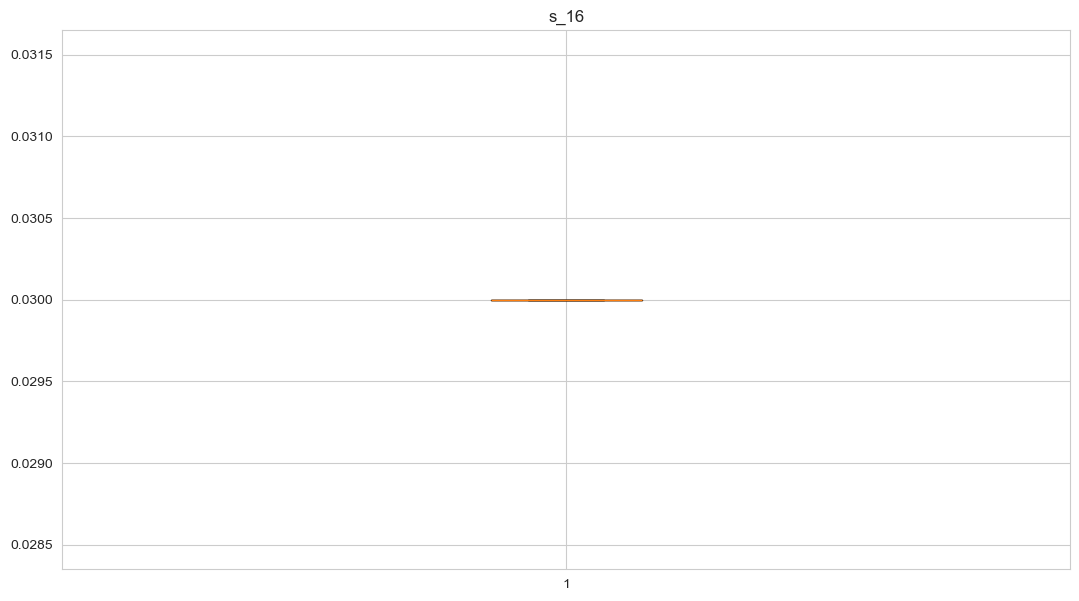

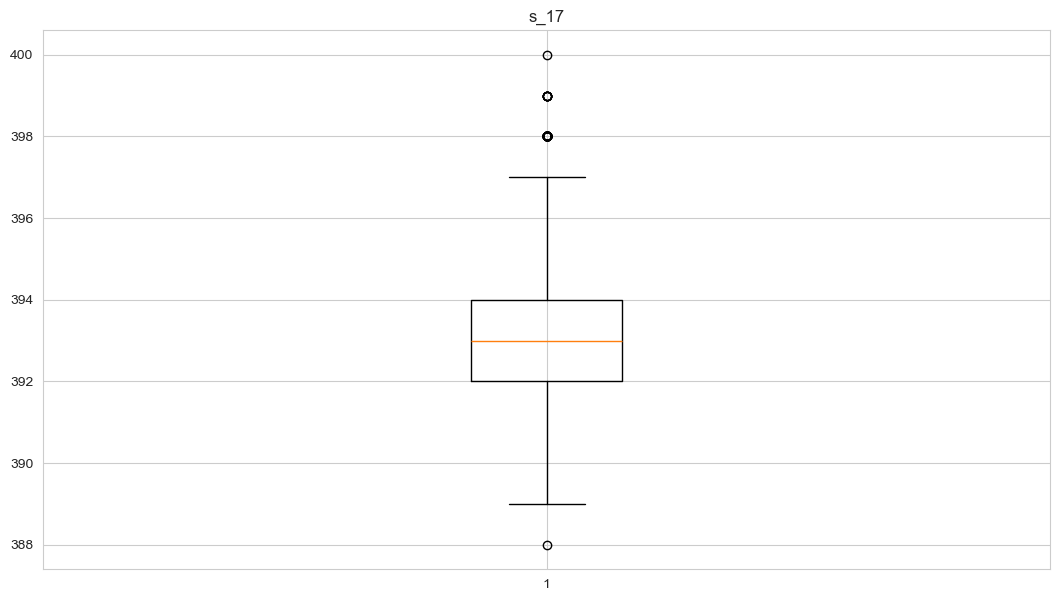

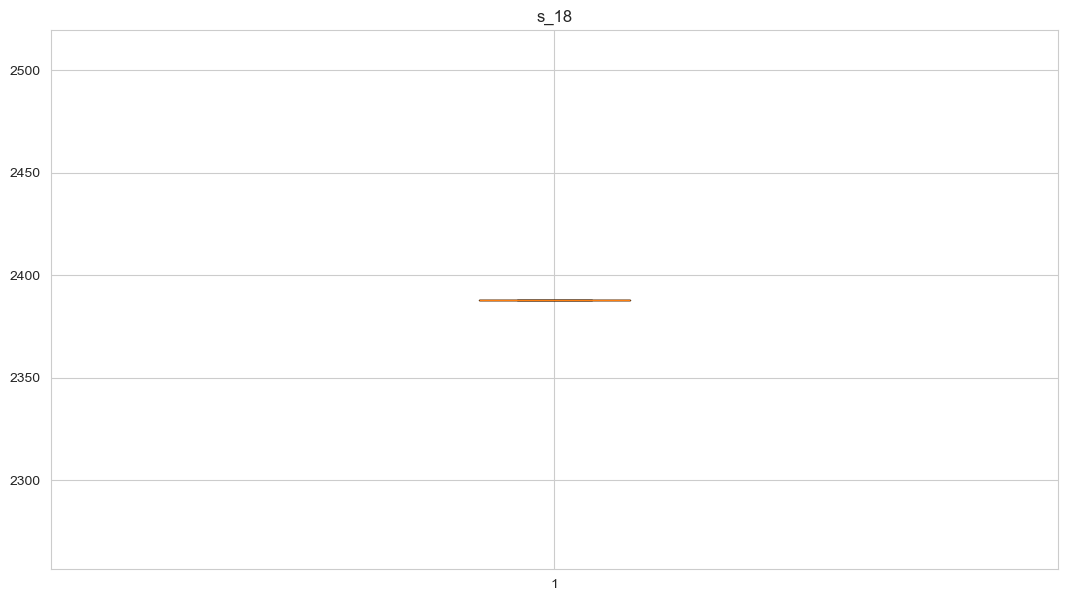

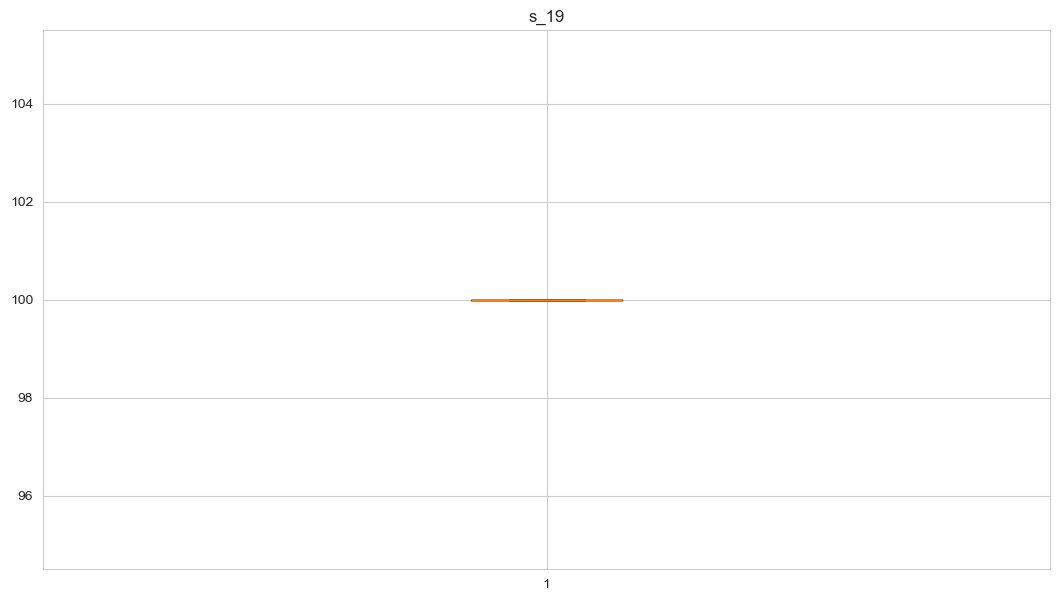

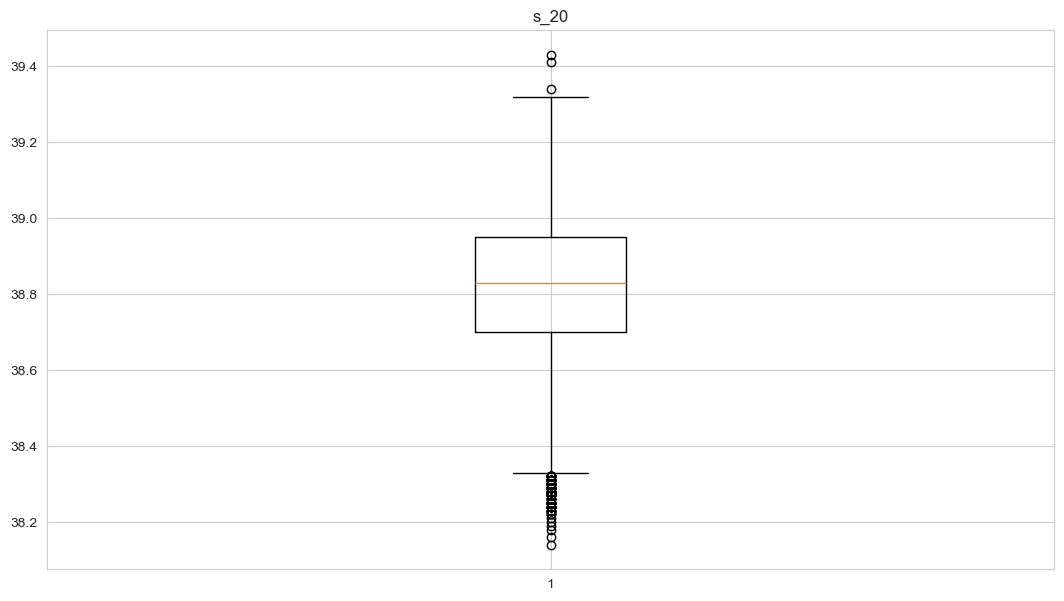

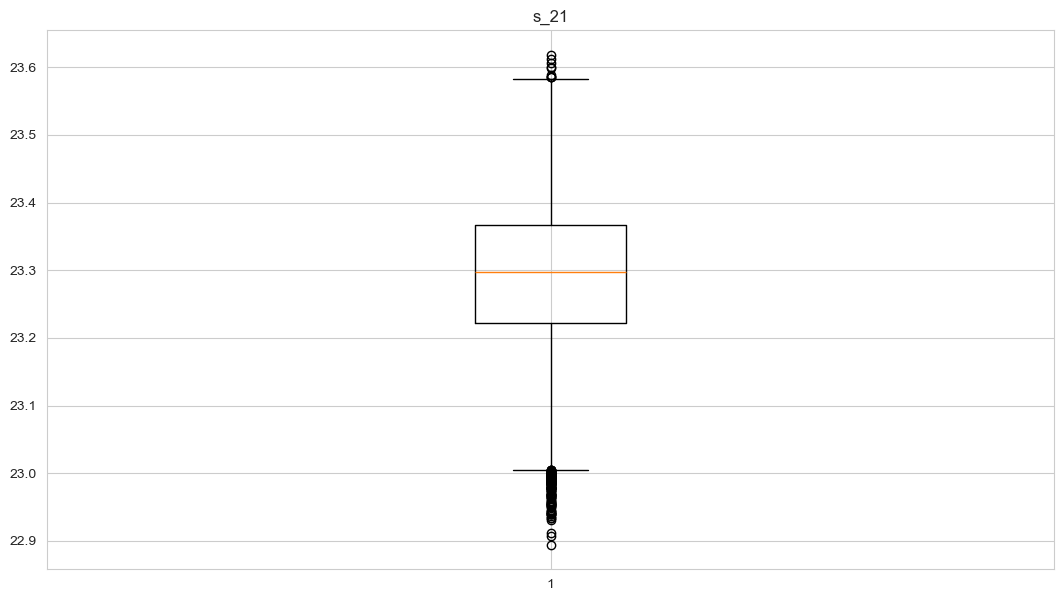

In [22]:
#繪製所有 sensor 欄位的箱型圖（Boxplot），目的是觀察每個 sensor 的數值分布和離群值
for x in sensor_names:
    plt.figure(figsize=(13,7))
    plt.boxplot(train[x])
    plt.title(x)
    plt.show()

Observing the signal plots and the boxplots, we notice that the sensors 1,5,10,16,18,19 are constant, furthermore, we observe that the other sensors aren't well distributed and there are many outliers, then we should scale our data

In [23]:
train.loc[:,'s_1':].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
s_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200
s_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
s_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
s_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s_10,20631.0,1.300000,4.660829e-13,1.3000,1.3000,1.3000,1.3000,1.3000


 The last point is more supported by the fact that the statistic properties of sensors data show that they don't have the same scale and they don't follow a normal distribution ==> this can be solved by performing a Minmax scaler on our data.
 感測器資料的統計特性表明它們不具有相同的尺度並且不遵循常態分佈 ==> 這可以透過對我們的資料執行 Minmax 縮放器來解決

**MinMax scaler function** :Transform features by scaling each feature to a given range.

This estimator scales and translates each feature individually such that it is in the given range on the training set
![image.png](attachment:e5a37840-e37f-4c7e-9344-5d956981932a.png)!

##### Dropping unnecessary features (labels and settings)

In [24]:
#切分資料集成feature / target
from sklearn.model_selection import train_test_split
y = train['RUL']
drop_labels = index_names+setting_names + ['RUL']
X=train.drop(columns=drop_labels).copy()
X_train, X_valid, y_train, y_valid=train_test_split(X,y, test_size=0.3, random_state=42)
#train_test_split(X(feature), y(taget), test_size=0.3(train跟valid比例 照理來說是test但因為這個資料集已先把test分出來), random_state=42(讓分割結果固定可重現))

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#Droping the target variable
#X_train.drop(columns=['RUL'], inplace=True)
#X_valid.drop(columns=['RUL'], inplace=True)
#Scaling X_train and X_valid
X_train_s=scaler.fit_transform(X_train)
X_valid_s=scaler.transform(X_valid)
#Conserve only the last occurence of each unit to match the length of y_valid
#驗證集(模擬測驗，調整學習策略)
drop_labels_for_test = index_names+setting_names

X_test_ = test_.groupby('unit_number').last().reset_index().drop(columns=drop_labels_for_test)
#scaling X_test_
X_test_s=scaler.transform(X_test_)


##### Scaling the data

In [26]:
print(X_test_s.shape)
print(y_valid.shape)


(100, 21)
(6190,)


#### plotting features new distribution

array([[<Axes: title={'center': 's_2'}>, <Axes: title={'center': 's_3'}>,
        <Axes: title={'center': 's_4'}>, <Axes: title={'center': 's_7'}>],
       [<Axes: title={'center': 's_8'}>, <Axes: title={'center': 's_9'}>,
        <Axes: title={'center': 's_11'}>,
        <Axes: title={'center': 's_12'}>],
       [<Axes: title={'center': 's_13'}>,
        <Axes: title={'center': 's_14'}>,
        <Axes: title={'center': 's_15'}>,
        <Axes: title={'center': 's_17'}>],
       [<Axes: title={'center': 's_20'}>,
        <Axes: title={'center': 's_21'}>, <Axes: >, <Axes: >]],
      dtype=object)

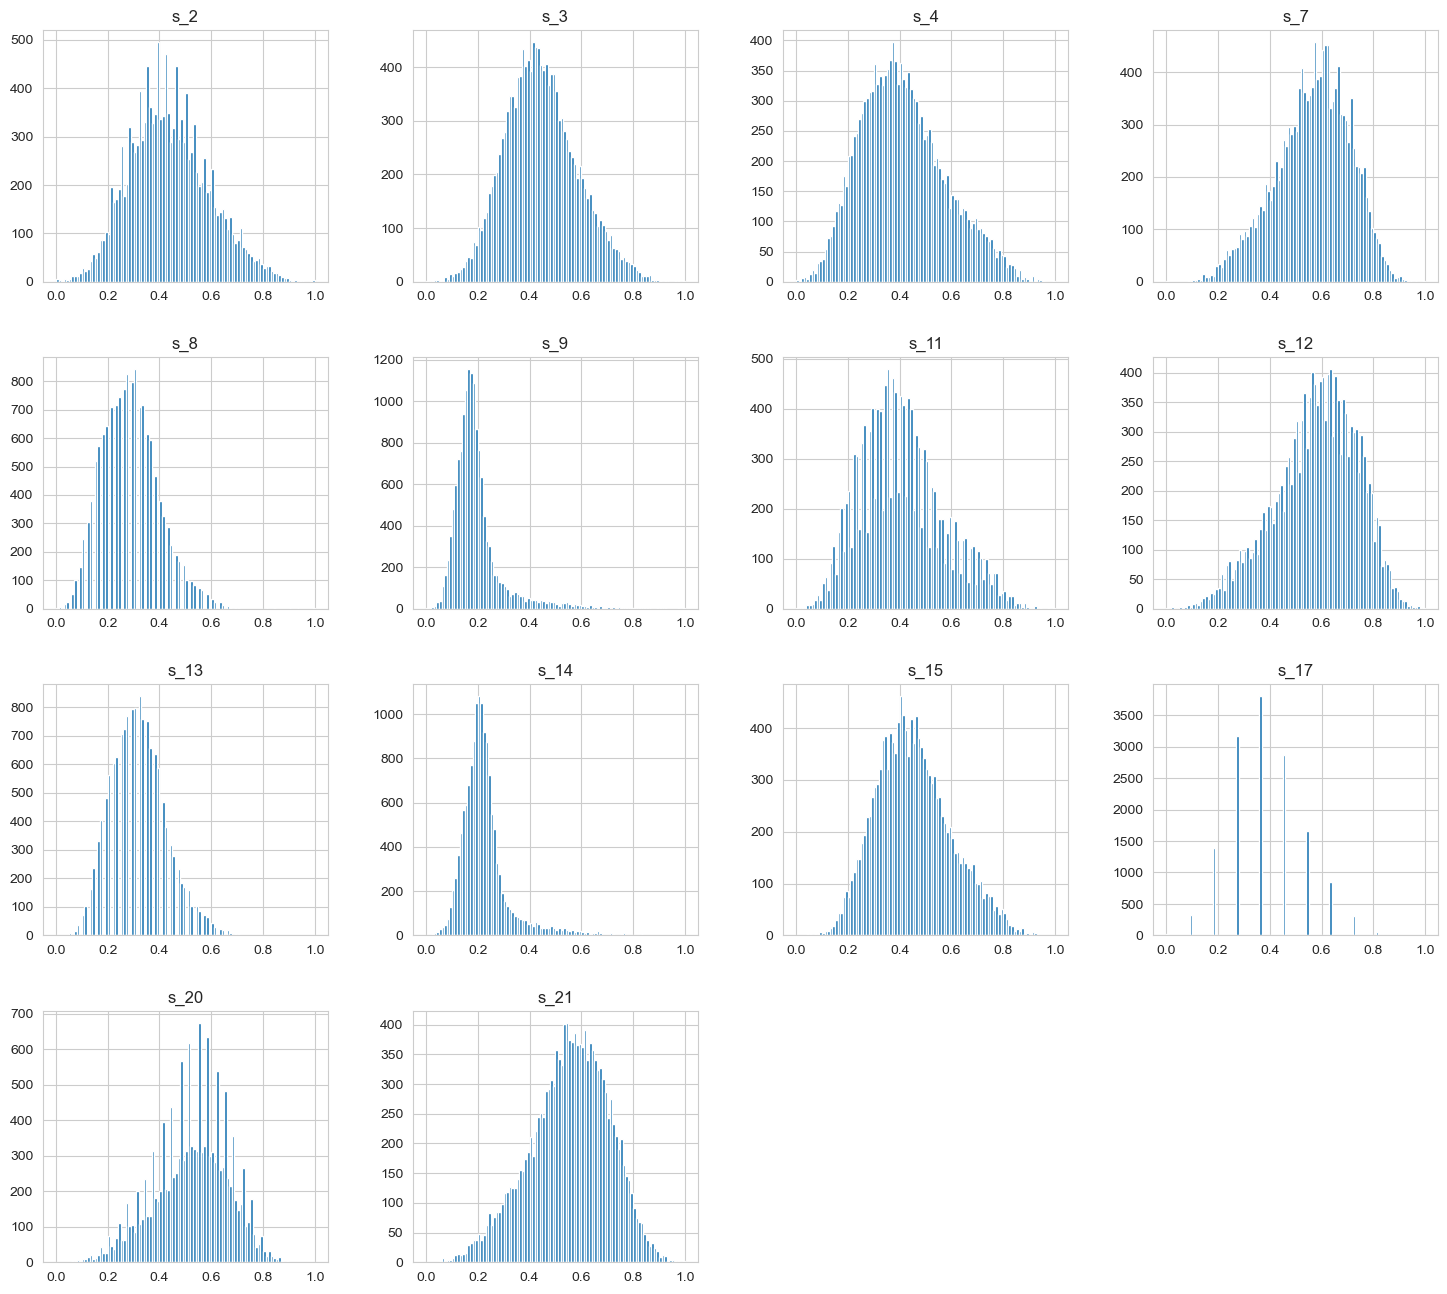

In [27]:
sensor_names=['s_{}'.format(i) for i in range(1,22) if i not in [1,5,6,10,16,18,19]]
pd.DataFrame(X_train_s,columns=['s_{}'.format(i) for i in range(1,22)])[sensor_names].hist(bins=100, figsize=(18,16))

## Models Implementation and instantiation

VAE EMBEDDING MODEL

1️⃣ 匯入套件

In [28]:
!pip install torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

存取被拒。


In [29]:
## 假設 X_train_s, X_valid_s 已經是 numpy array
#把 numpy array 轉成 PyTorch tensor(張量)，才能餵給神經網路訓練
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
#將 tensor 封裝成 TensorDataset 物件 ??為何要封裝
train_dataset = TensorDataset(X_train_tensor)
#DataLoader 會將 dataset 分批次取出，每次取 32 筆資料
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

2️⃣ 準備資料

3️⃣ 定義 VAE 架構

In [30]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 64)
        self.fc3 = nn.Linear(64, input_dim)

        self.relu = nn.ReLU()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        mu = self.fc_mu(h1)
        logvar = self.fc_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h2 = self.relu(self.fc2(z))
        return self.fc3(h2)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

4️⃣ 定義損失函數（VAE Loss）

In [31]:
def vae_loss(x_hat, x, mu, logvar):
    # 重建誤差
    recon_loss = nn.MSELoss()(x_hat, x)
    # KL 散度
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss*0.0001  # 可以調整權重


In [32]:
import os
import torch

# 🔹 模型設定
input_dim = X_train_s.shape[1]
latent_dim = 2
save_path = r"C:\Users\User\Desktop\kaggle 專案\nasa專案\vae_model.pth"

# 🔹 是否強制重新訓練
force_train = False   # 👈 改成 True 即可強制重新訓練

# 🔹 建立模型與 optimizer
vae = VAE(input_dim, latent_dim)
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)

# 🔹 檢查是否已有模型
if os.path.exists(save_path) and not force_train:
    vae.load_state_dict(torch.load(save_path))
    vae.eval()
    print(f"✅ 已載入既有模型：{save_path}")
else:
    if force_train:
        print("⚙️ force_train=True → 強制重新訓練模型")
    else:
        print("🚀 未找到已存在模型 → 開始訓練")

    # 🔸 模型訓練
    epochs = 50
    vae.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            x_batch = batch[0]
            optimizer.zero_grad()
            x_hat, mu, logvar = vae(x_batch)
            loss = vae_loss(x_hat, x_batch, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

    # 🔹 儲存模型
    torch.save(vae.state_dict(), save_path)
    print(f"✅ 模型已儲存至：{save_path}")

# 🔹 切換為推論模式
vae.eval()
print("✅ 模型目前處於推論模式 (eval mode)")


✅ 已載入既有模型：C:\Users\User\Desktop\kaggle 專案\nasa專案\vae_model.pth
✅ 模型目前處於推論模式 (eval mode)


5️⃣ 訓練 VAE

6️⃣ 保存 Encoder

In [33]:
X_train_s.shape

(14441, 21)

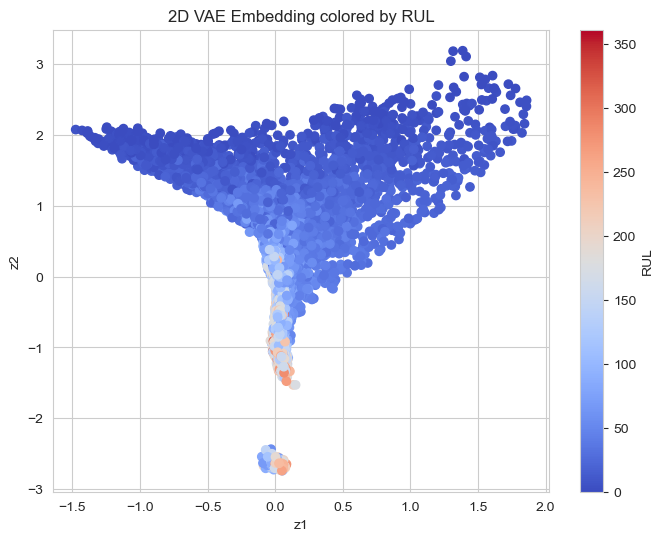

In [34]:
vae.eval()
with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
    mu, logvar = vae.encode(X_train_tensor)
    embeddings = mu.numpy()  # 使用均值作為 embedding

y_train_array = y_train.values  # 取出 RUL
plt.figure(figsize=(8,6))
plt.scatter(embeddings[:,0], embeddings[:,1], c=y_train_array, cmap='coolwarm')
plt.colorbar(label='RUL')
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('2D VAE Embedding colored by RUL')
plt.show()


# 試著只看其中幾台引擎的 EMBEDDING,觀察圖你發現了甚麼

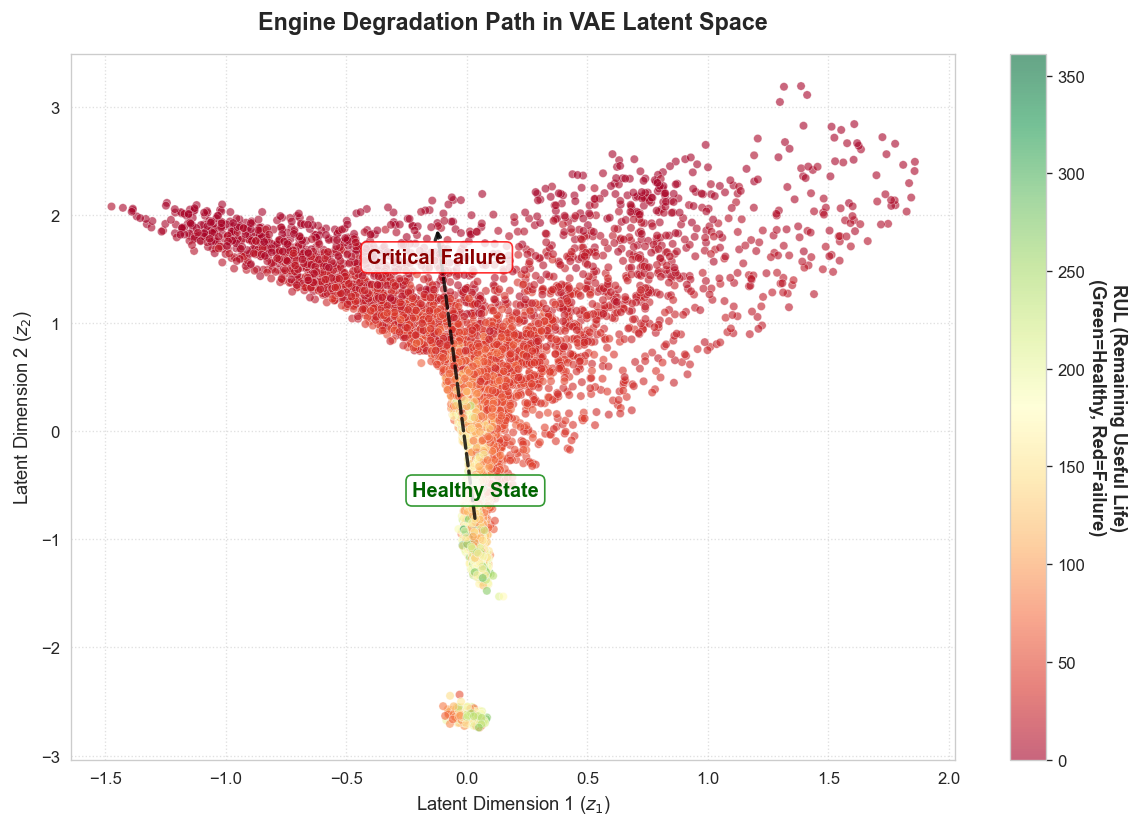

In [35]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# --- 1. 取得 Embedding (保留你的原始邏輯) ---
vae.eval()
with torch.no_grad():
    # 確保這裡的 X_train_s 是正確的變數名稱
    X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
    mu, logvar = vae.encode(X_train_tensor)
    embeddings = mu.numpy()  # 使用均值作為 embedding

y_train_array = y_train.values  # 取出 RUL

# --- 2. 簡報級繪圖優化 (Presentation Ready Plot) ---
plt.figure(figsize=(10, 7), dpi=120)  # 提高解析度 (DPI) 讓簡報更清晰

# 設定顏色映射：RdYlGn (紅-黃-綠)
# 預設是對應 0(紅) -> Max(綠)，完美符合 RUL 0=故障 -> RUL High=健康
cmap = plt.get_cmap('RdYlGn')

# 繪製散佈圖
scatter = plt.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    c=y_train_array,
    cmap=cmap,
    s=25,           # 點稍微大一點
    alpha=0.6,      # 透明度，讓重疊部分顯示密度
    edgecolors='w', # 加上白色微邊框，讓點更立體
    linewidth=0.3
)

# Colorbar 優化
cbar = plt.colorbar(scatter)
cbar.set_label('RUL (Remaining Useful Life)\n(Green=Healthy, Red=Failure)',
               rotation=270, labelpad=25, fontsize=11, fontweight='bold')

# --- 3. 自動計算並標註「退化方向」 (自動說故事) ---
# 找出 RUL 最低 (故障) 和 RUL 最高 (健康) 的前 5% 數據點的中心位置
low_rul_threshold = np.percentile(y_train_array, 5)
high_rul_threshold = np.percentile(y_train_array, 95)

mask_fail = y_train_array <= low_rul_threshold
mask_healthy = y_train_array >= high_rul_threshold

# 只有當同時存在健康和故障數據時才畫箭頭
if np.any(mask_fail) and np.any(mask_healthy):
    # 計算中心點 (Centroids)
    center_fail = np.mean(embeddings[mask_fail], axis=0)
    center_healthy = np.mean(embeddings[mask_healthy], axis=0)

    # 1. 畫箭頭：從健康指向故障
    plt.annotate(
        '',
        xy=center_fail,          # 箭頭尖端 (故障)
        xytext=center_healthy,   # 箭頭尾端 (健康)
        arrowprops=dict(arrowstyle="->", color='black', lw=2, linestyle='--', alpha=0.8)
    )

    # 2. 標註文字：Healthy
    plt.text(
        center_healthy[0], center_healthy[1] + 0.2,
        'Healthy State',
        fontsize=12, fontweight='bold', color='darkgreen',
        ha='center', va='bottom',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8)
    )

    # 3. 標註文字：Failure
    plt.text(
        center_fail[0], center_fail[1] - 0.2,
        'Critical Failure',
        fontsize=12, fontweight='bold', color='darkred',
        ha='center', va='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8)
    )

# --- 4. 標題與軸標籤 ---
plt.xlabel('Latent Dimension 1 ($z_1$)', fontsize=11)
plt.ylabel('Latent Dimension 2 ($z_2$)', fontsize=11)
plt.title('Engine Degradation Path in VAE Latent Space', fontsize=14, fontweight='bold', pad=15)

plt.grid(True, linestyle=':', alpha=0.6) # 加入淡淡的網格方便對齊
plt.tight_layout()
plt.show()

[-0.31691843  1.7064843 ]


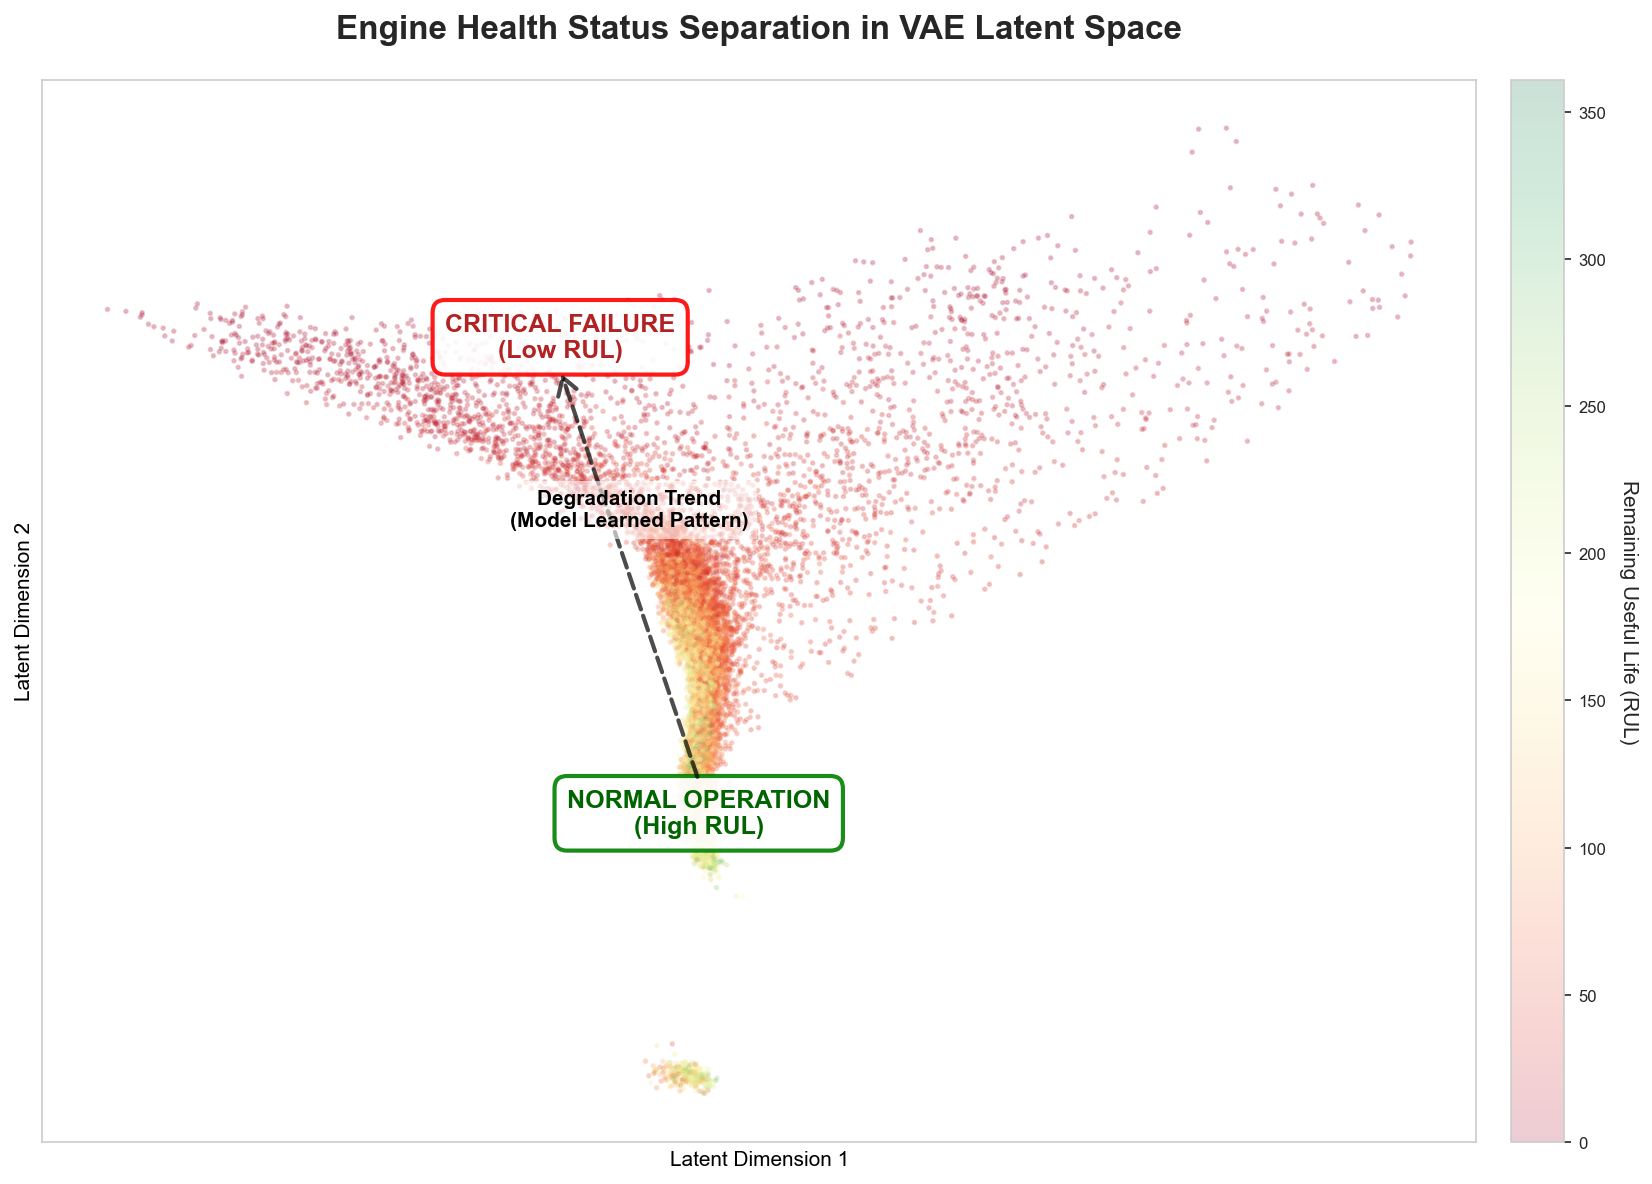

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import numpy as np

# --- 1. 取得 Embedding (維持你的原始邏輯) ---
vae.eval()
with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
    mu, logvar = vae.encode(X_train_tensor)
    embeddings = mu.numpy()

y_train_array = y_train.values

# --- 2. 簡報級視覺優化 ---
plt.figure(figsize=(12, 8), dpi=150) # 高解析度
ax = plt.gca() # 取得目前的軸物件

# 設定顏色：使用 RdYlGn (紅-黃-綠)，讓 綠=健康, 紅=故障
cmap = plt.get_cmap('RdYlGn')

# A. 畫背景點 (Background Points)
# 關鍵：點設得非常小 (s=3) 且透明 (alpha=0.2)
# 這樣重疊的地方會變深色，顯示出「資料密度」，看起來像熱力圖，非常專業
scatter = plt.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    c=y_train_array,
    cmap=cmap,
    s=3,            # 點縮小，讓畫面細緻
    alpha=0.2       # 高透明度，強調分佈密度
)

# B. 自動計算關鍵區域 (Auto-Annotation)
# 找出 RUL 最高 (健康) 與 最低 (故障) 的區域中心
high_rul_mask = y_train_array > np.percentile(y_train_array, 90) # 前 10% 健康
low_rul_mask = y_train_array < np.percentile(y_train_array, 10)  # 後 10% 故障

center_healthy = np.median(embeddings[high_rul_mask], axis=0)
center_failure = np.median(embeddings[low_rul_mask], axis=0)

# C. 加上強烈的視覺引導 (Storytelling Elements)

# 1. 標註「健康區」
plt.text(
    center_healthy[0], center_healthy[1]-0.2,
    'NORMAL OPERATION\n(High RUL)',
    fontsize=12, fontweight='bold', color='darkgreen',
    ha='center', va='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="green", alpha=0.9, lw=2)
)

# 2. 標註「故障區」
plt.text(
    center_failure[0], center_failure[1]+0.2,
    'CRITICAL FAILURE\n(Low RUL)',
    fontsize=12, fontweight='bold', color='firebrick',
    ha='center', va='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="red", alpha=0.9, lw=2)
)

# 3. 畫出巨大的「退化趨勢箭頭」 (Project Purpose)
# 告訴觀眾：我們的模型學會了這個方向！
arrow_xy = center_failure.copy()
arrow_xy[0]+=10
arrow_xy[1]+=10
print(center_failure)
plt.annotate(
    '',
    xy=center_failure,
    xytext=center_healthy,
    arrowprops=dict(arrowstyle="->,head_width=0.5,head_length=0.8",
                    color='black', lw=2, linestyle='--', alpha=0.7)
)

# 在箭頭中間寫上專案核心價值
mid_point = (center_healthy + center_failure) / 2
plt.text(
    mid_point[0], mid_point[1] + 0.3,
    'Degradation Trend\n(Model Learned Pattern)',
    fontsize=10, fontweight='bold', color='black', ha='center',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.6)
)

# --- 4. 調整標題與細節 ---
# 隱藏刻度 (簡報時，Latent Space 的具體數值不重要，形狀才重要)
plt.xticks([])
plt.yticks([])
plt.xlabel('Latent Dimension 1', fontsize=10, color='black')
plt.ylabel('Latent Dimension 2', fontsize=10, color='black')

# Colorbar 放在旁邊作為輔助
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Remaining Useful Life (RUL)', rotation=270, labelpad=15)
cbar.ax.tick_params(labelsize=8)

# 主標題 (清楚說明這張圖是什麼)
plt.title('Engine Health Status Separation in VAE Latent Space', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [37]:
X_train_s.shape

(14441, 21)

Support set shape: torch.Size([14441, 2])
🔹 準確率: 0.85

🔹 分類報告:
              precision    recall  f1-score   support

         Low       0.96      0.81      0.88        67
        High       0.70      0.94      0.81        33

    accuracy                           0.85       100
   macro avg       0.83      0.87      0.84       100
weighted avg       0.88      0.85      0.85       100



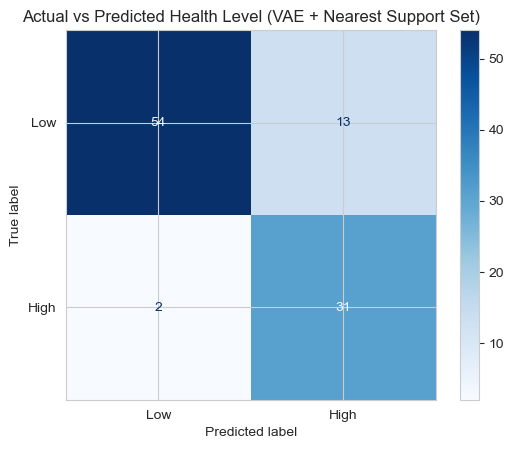

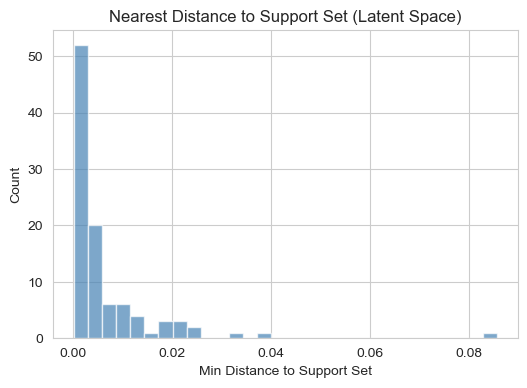

In [38]:
# 2️⃣ 用 VAE encoder 生成 embedding
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt

vae.eval()  # 切換成推論模式，不更新參數

# 將 test data 轉成 tensor
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)

with torch.no_grad():
    mu_test, logvar_test = vae.encode(X_test_tensor)
    z_test = mu_test  # 使用平均值作為 embedding（比取樣穩定）

# 🔹 將 training data 作為 support set
with torch.no_grad():
    mu_train, logvar_train = vae.encode(torch.tensor(X_train_s, dtype=torch.float32))
    z_train = mu_train

support_set = z_train  # support set = 訓練集的 embedding
print(f"Support set shape: {support_set.shape}")

# ----------------------------------------------------
# 🔸 Step 1. 根據 RUL 建立 support set 的實際標籤
# ----------------------------------------------------
y_train_array = np.array(y_train)
low_th_rul, high_th_rul = np.quantile(y_train_array, [0.33, 0.66])

support_labels = []
for r in y_train_array:
    if r > low_th_rul:
        support_labels.append("Low")      # RUL 高 → 還健康
    else:
        support_labels.append("High")     # RUL 低 → 快壞掉
support_labels = np.array(support_labels)

# ----------------------------------------------------
# 🔸 Step 2. 對每個 test data，找出最近的 support set
# ----------------------------------------------------
pred_labels = []
nearest_distances = []

for _z in z_test:
    distances = torch.norm(_z - support_set, dim=1).numpy()  # 計算與所有 support 的距離
    min_idx = np.argmin(distances)                           # 找出最近的 support set
    pred_labels.append(support_labels[min_idx])              # 取該 support 的 label
    nearest_distances.append(distances[min_idx])             # 記錄最小距離（可視覺化）

pred_labels = np.array(pred_labels)

# ----------------------------------------------------
# 🔸 Step 3. 建立 test set 的實際標籤 (根據 RUL)
# ----------------------------------------------------
y_test_array = np.array(y_test)
low_th_rul, high_th_rul = np.quantile(y_test_array, [0.33, 0.66])

test_labels = []#風險高低
# for r in y_test_array:
#     if r > high_th_rul:
#         test_labels.append("Low")      # RUL 高 → 還健康
#     elif r > low_th_rul:
#         test_labels.append("Medium")
#     else:
#         test_labels.append("High")     # RUL 低 → 快壞掉

for r in y_test_array:
    if r > low_th_rul:
        test_labels.append("Low")      # RUL 高 → 還健康
    else:
        test_labels.append("High")     # RUL 低 → 快壞掉
test_labels = np.array(test_labels)

# ----------------------------------------------------
# 🔸 Step 4. 計算準確率與分類報告
# ----------------------------------------------------
accuracy = accuracy_score(test_labels, pred_labels)
print(f"🔹 準確率: {accuracy:.2f}")

print("\n🔹 分類報告:")
print(classification_report(test_labels, pred_labels, labels=["Low", "High"]))

# ----------------------------------------------------
# 🔸 Step 5. 混淆矩陣可視化
# ----------------------------------------------------
labels = ["Low", "High"]
cm = confusion_matrix(test_labels, pred_labels, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Actual vs Predicted Health Level (VAE + Nearest Support Set)")
plt.show()

# ----------------------------------------------------
# 🔸 Step 6. 額外畫距離分布圖（觀察最近距離的分布）
# ----------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(nearest_distances, bins=30, color='steelblue', alpha=0.7)
plt.title("Nearest Distance to Support Set (Latent Space)")
plt.xlabel("Min Distance to Support Set")
plt.ylabel("Count")
plt.show()


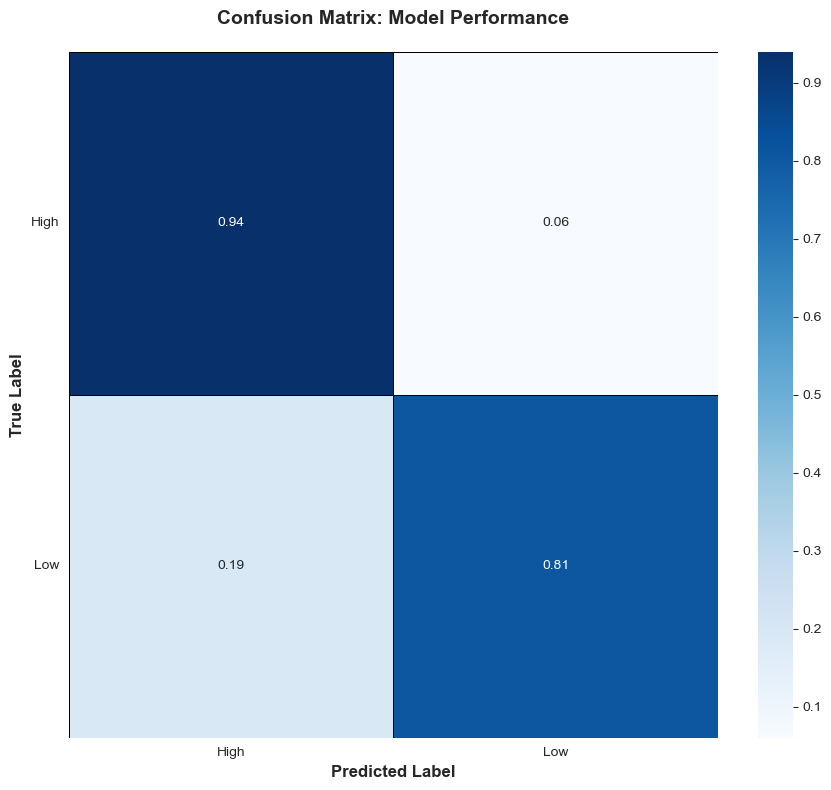


Classification Report:
              precision    recall  f1-score   support

        High       0.70      0.94      0.81        33
         Low       0.96      0.81      0.88        67

    accuracy                           0.85       100
   macro avg       0.83      0.87      0.84       100
weighted avg       0.88      0.85      0.85       100



In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd 
from sklearn.metrics import mean_squared_error, r2_score

# 設定畫圖風格
sns.set_style("whitegrid")

def plot_hero_shot(y_true, y_pred,title='Confusion Matrix: Model Performance'):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # 2. 獲取所有唯一的類別標籤
    # 使用 set 確保類別順序一致性，若需要特定順序（如 Low, Medium, High），請自行定義
    labels = sorted(list(set(y_true) | set(y_pred)))
    
    # 如果您希望有特定的順序，例如：
    # labels = ['Low', 'Medium', 'High'] 
    
    # 3. 計算混淆矩陣
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # 4. 計算整體準確率
    accuracy = accuracy_score(y_true, y_pred)
    
    # 5. 正規化混淆矩陣 (顯示百分比，讓結果更容易解讀)
    # axis=1 表示對每一行 (真實值) 進行正規化
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(9, 8))

    # 繪製熱力圖 
    sns.heatmap(cm_normalized, 
                annot=True, # 顯示數值
                fmt='.2f',  # 顯示小數點後兩位 (百分比)
                cmap='Blues', # 使用藍色調色盤
                cbar=True,  # 顯示顏色條
                linewidths=0.5, 
                linecolor='black',
                xticklabels=labels, 
                yticklabels=labels)

    # 設置標籤與標題
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    
    # 添加總體準確度到標題
    full_title = f"{title}"
    plt.title(full_title, fontsize=14, fontweight='bold', pad=20)
    
    plt.yticks(rotation=0) # 確保 Y 軸標籤是水平的
    plt.tight_layout()
    plt.show()
    
    # 額外打印詳細的分類報告
    print("\n" + "="*50)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=labels))
    print("="*50)
    
# # 呼叫函式 (請用您實際的 y_test 和 pred_labels 變數替換)
plot_hero_shot(test_labels, pred_labels)